## Comprobación del número de píxeles de cada clase

In [1]:
import numpy as np
import glob
import os

def read_seg_centers(fichero):
    """Lee el fichero de centros (.raw) y devuelve los índices de los píxeles centrales."""
    try:
        #Los centros suelen tener cabecera: H, V, nseg (uint32)
        cabecera = np.fromfile(fichero, count=3, dtype=np.uint32)
        H, V, nseg = cabecera
        # El resto son los índices de los centros
        datos = np.fromfile(fichero, count=H*V, offset=3*4, dtype=np.uint32)
        #Filtramos posibles valores nulos o fuera de rango si nseg es menor que H*V
        return datos, nseg
    except Exception as e:
        print(f"Error leyendo centros {fichero}: {e}")
        return None, 0

def leer_clases_pgm(ruta_archivo):
    """Lee el PGM y devuelve un array plano con la clase de cada píxel."""
    try:
        with open(ruta_archivo, 'rb') as f:
            tipo = f.readline().decode().strip()
            if tipo != 'P5': return None
            
            linea = f.readline().decode()
            while linea.startswith('#') or not linea.strip():
                linea = f.readline().decode()
            
            dimensiones = linea.split()
            while len(dimensiones) < 2:
                dimensiones += f.readline().decode().split()
            
            ancho, alto = map(int, dimensiones[:2])
            linea_max = f.readline().decode().strip()
            while not linea_max or linea_max.startswith('#'):
                linea_max = f.readline().decode().strip()
            max_val = int(linea_max)

            dtype = np.uint8 if max_val < 256 else np.uint16
            datos = np.frombuffer(f.read(), dtype=dtype)
            return datos, max_val
    except Exception as e:
        print(f"Error leyendo PGM {ruta_archivo}: {e}")
        return None, 0

def procesar_dataset(ruta_pgm, ruta_centers):
    """Asocia cada centro de segmento con su clase en el PGM y cuenta."""
    clases_pixeles, max_clase = leer_clases_pgm(ruta_pgm)
    indices_centros, n_segmentos = read_seg_centers(ruta_centers)
    
    if clases_pixeles is None or indices_centros is None:
        return None

    #Obtenemos la clase de cada segmento consultando el PGM en la posición del centro
    #indices_centros contiene el índice plano (y * H + x)
    clases_de_segmentos = clases_pixeles[indices_centros]
    
    #Contamos segmentos por clase
    conteo = np.bincount(clases_de_segmentos, minlength=max_clase + 1)
    
    return {i: int(cantidad) for i, cantidad in enumerate(conteo) if cantidad > 0}

# --- CONFIGURACIÓN DE RUTAS ---
directorio_base = "datosEntrada"
# Buscamos los PGM (Ground Truth)
archivos_pgm = glob.glob(os.path.join(directorio_base, "**", "*.pgm"), recursive=True)

if not archivos_pgm:
    print(f"No se encontraron archivos en: {os.path.abspath(directorio_base)}")
else:
    print(f"*** Procesando {len(archivos_pgm)} datasets (Conteo por Segmentos) ***\n")
    
    for ruta_pgm in archivos_pgm:
        #Intentamos encontrar el archivo de centros correspondiente
        carpeta = os.path.dirname(ruta_pgm)
        ficheros_en_carpeta = os.listdir(carpeta)
        
        # Buscamos un fichero que contenga 'centers.raw'
        ruta_centers = None
        for f in ficheros_en_carpeta:
            if "centers.raw" in f.lower():
                ruta_centers = os.path.join(carpeta, f)
                break
        
        if not ruta_centers:
            print(f"SALTANDO: No se encontró archivo de centros para {ruta_pgm}")
            continue

        print(f"DATASET: {os.path.basename(carpeta)}")
        print(f"PGM: {os.path.basename(ruta_pgm)}")
        print(f"CENTROS: {os.path.basename(ruta_centers)}")
        
        resultado = procesar_dataset(ruta_pgm, ruta_centers)

        if resultado:
            total_sin_clase_0 = sum(cant for val, cant in resultado.items() if val != 0)
            total_absoluto = sum(resultado.values())
            
            print(f"{'Clase':<10} | {'Segmentos':<15} | {'% (Útiles)':<10}")
            print("-" * 45)
            
            for valor in sorted(resultado.keys()):
                cantidad = resultado[valor]
                if valor == 0:
                    print(f"{valor:<10} | {cantidad:<15} | {'(Sin etiqueta)':>10}")
                else:
                    porcentaje = (cantidad / total_sin_clase_0) * 100 if total_sin_clase_0 > 0 else 0
                    print(f"{valor:<10} | {cantidad:<15} | {porcentaje:>9.2f}%")

            print("-" * 45)
            print(f"Total segmentos con clase (>0): {total_sin_clase_0} ({total_sin_clase_0/total_absoluto*100:.2f}%)")
            print(f"Total segmentos sin clase (0): {total_absoluto-total_sin_clase_0} ({(total_absoluto-total_sin_clase_0)/total_absoluto*100:.2f}%)")
            print(f"Total segmentos imagen:         {total_absoluto}")
        else:
            print(f"Error: No se pudo procesar el dataset.")
        
        print("\n" + "="*50 + "\n")

*** Procesando 8 datasets (Conteo por Segmentos) ***

DATASET: oitaven
PGM: oitaven_river.pgm
CENTROS: seg_oitaven_wp_centers.raw
Clase      | Segmentos       | % (Útiles)
---------------------------------------------
0          | 114531          | (Sin etiqueta)
1          | 912             |      4.21%
2          | 484             |      2.24%
3          | 349             |      1.61%
4          | 128             |      0.59%
5          | 458             |      2.12%
6          | 294             |      1.36%
7          | 6896            |     31.86%
8          | 7573            |     34.98%
9          | 955             |      4.41%
10         | 3599            |     16.63%
---------------------------------------------
Total segmentos con clase (>0): 21648 (15.90%)
Total segmentos sin clase (0): 114531 (84.10%)
Total segmentos imagen:         136179


DATASET: xesta
PGM: xesta_basin.pgm
CENTROS: seg_xesta_wp_centers.raw
Clase      | Segmentos       | % (Útiles)
-----------------------

In [2]:
import numpy as np
import os
import glob

def contar_total_segmentos(ruta_seg):
    """
    Lee un archivo .raw de segmentación y devuelve el número total de segmentos únicos.
    """
    try:
        # 1. LECTURA DE LA CABECERA
        # Leemos los primeros 8 bytes (2 enteros de 32 bits) para el ancho y alto
        cabecera_seg = np.fromfile(ruta_seg, count=2, dtype=np.uint32)
        ancho_seg, alto_seg = cabecera_seg[0], cabecera_seg[1]
        
        # 2. LECTURA DE LOS PÍXELES
        # Leemos el resto saltando la cabecera
        segmentos_pixeles = np.fromfile(ruta_seg, count=ancho_seg * alto_seg, offset=8, dtype=np.uint32)
        
        # 3. CONTEO DE SEGMENTOS ÚNICOS
        total_segmentos = len(np.unique(segmentos_pixeles))
        
        return total_segmentos
    except Exception as e:
        print(f"Error procesando {ruta_seg}: {e}")
        return None


# =========================================================
# SCRIPT PRINCIPAL
# =========================================================
directorio_base = "datosEntrada"
# Buscamos todos los archivos que empiecen por "seg_" y terminen en ".raw"
patron_busqueda = os.path.join(directorio_base, "**", "seg_*.raw")
archivos_raw = glob.glob(patron_busqueda, recursive=True)

# Filtramos para descartar los archivos que contienen los centros
archivos_seg = [archivo for archivo in archivos_raw if not archivo.endswith("_centers.raw")]

if not archivos_seg:
    print(f"No se encontraron archivos de segmentación en: {os.path.abspath(directorio_base)}")
else:
    print(f"*** Se han encontrado {len(archivos_seg)} archivos de segmentación ***\n")
    
    # Imprimimos la cabecera de la tabla
    print(f"{'Carpeta / Archivo':<45} | {'Total Segmentos':<15}")
    print("-" * 65)
    
    # Recorremos los archivos ordenados alfabéticamente
    for archivo in sorted(archivos_seg):
        total = contar_total_segmentos(archivo)
        
        if total is not None:
            # Extraemos el nombre de la carpeta y del archivo para que la tabla sea legible
            nombre_carpeta = os.path.basename(os.path.dirname(archivo))
            nombre_archivo = os.path.basename(archivo)
            nombre_corto = f"{nombre_carpeta}/{nombre_archivo}"
            
            print(f"{nombre_corto:<45} | {total:<15,}".replace(',', '.')) # Formato con puntos para miles
        else:
            print(f"{os.path.basename(archivo):<45} | {'Error':<15}")
            
    print("-" * 65)
    print("¡Conteo finalizado!\n")

*** Se han encontrado 8 archivos de segmentación ***

Carpeta / Archivo                             | Total Segmentos
-----------------------------------------------------------------
das_mestas/seg_mestas_wp.raw                  | 151.531        
eiras_dam/seg_eiras_wp.raw                    | 282.672        
ermidas_creek/seg_ermidas_wp.raw              | 651.257        
ferreiras_river/seg_ferreiras_wp.raw          | 271.469        
mera_river/seg_mera_wp.raw                    | 743.522        
oitaven/seg_oitaven_wp.raw                    | 136.179        
ulla/seg_ulla_wp.raw                          | 257.297        
xesta/seg_xesta_wp.raw                        | 216.211        
-----------------------------------------------------------------
¡Conteo finalizado!



In [3]:
import os
import numpy as np
import math
import glob

def read_pgm_lite(fichero):
    """Lee el Ground Truth para obtener las etiquetas."""
    with open(fichero, "rb") as pgmf:
        header = pgmf.readline().decode()
        line = pgmf.readline().decode()
        while line[0] == '#': line = pgmf.readline().decode()
        (H, V) = map(int, line.split())
        depth = int(pgmf.readline().decode())
        raster = list(pgmf.read(H * V))
    return raster, H, V

def read_seg_centers_lite(fichero):
    """Lee los centros de los segmentos."""
    header = np.fromfile(fichero, count=3, dtype=np.uint32)
    H, V, nseg = header[0], header[1], header[2]
    datos = np.fromfile(fichero, count=H*V, offset=3*4, dtype=np.uint32)
    return datos, H, V, nseg

def calcular_muestras_esperadas_sampler(counts_train):
    """
    Calcula la distribución estadística que genera el WeightedRandomSampler
    usando la fórmula: weight = 1.0 / sqrt(count) / 2
    """
    total_train = sum(counts_train)
    if total_train == 0: return [0] * len(counts_train)

    # 1. Aplicar fórmula de pesos: w = 1 / (sqrt(N) * 2)
    pesos_clase = [1.0/math.sqrt(c) if c > 0 else 0.0 for c in counts_train]
    
    # 2. La probabilidad de elegir una clase es: (conteo_original * peso_clase)
    # Esto resulta en una distribución proporcional a sqrt(N)
    prob_relativa = [c * w for c, w in zip(counts_train, pesos_clase)]
    suma_prob = sum(prob_relativa)
    
    # 3. Muestras que se verán por época (frecuencia esperada)
    esperado = [(p / suma_prob) * total_train for p in prob_relativa]
    return esperado

# Configuración original
SAMPLES = [0.15, 0.05] # [entrenamiento, validacion]
sizex, sizey = 32, 32  # Tamaño del patch

def analizar_datasets(ruta_base):
    if not os.path.exists(ruta_base):
        print(f"Error: La carpeta '{ruta_base}' no existe.")
        return

    subcarpetas = sorted([f.path for f in os.scandir(ruta_base) if f.is_dir()])
    
    for folder in subcarpetas:
        nombre_dataset = os.path.basename(folder)
        print(f"\n{'='*85}")
        print(f" DATASET: {nombre_dataset.upper()}")
        print(f"{'='*85}")
        
        gt_file = glob.glob(os.path.join(folder, "*.pgm"))
        center_file = glob.glob(os.path.join(folder, "*_centers.raw"))
        
        if not gt_file or not center_file:
            print(f" [!] Faltan archivos .pgm o _centers.raw. Saltando...")
            continue
            
        truth, H, V = read_pgm_lite(gt_file[0])
        center, H3, V3, nseg = read_seg_centers_lite(center_file[0])
        
        nclases = max(truth)
        lista = [[] for _ in range(nclases)]
        
        # Filtrado de bordes
        xmin, xmax = int(sizex/2), H - int(math.ceil(sizex/2))
        ymin, ymax = int(sizey/2), V - int(math.ceil(sizey/2))

        for ind in center:
            i, j = ind // H, ind % H
            if i < ymin or i > ymax or j < xmin or j > xmax: continue
            if truth[ind] > 0:
                lista[truth[ind]-1].append(ind)

        # Listas para guardar el reparto de cada clase
        clases_ids = []
        counts_total = []
        counts_train = []
        counts_val = []
        counts_test = []

        for i in range(nclases):
            total_clase = len(lista[i])
            if total_clase == 0: continue
            
            # --- Lógica de reparto de SAMPLES ---
            # Train
            if SAMPLES[0] >= 1: tot0 = int(SAMPLES[0])
            else: tot0 = int(SAMPLES[0] * total_clase)
            
            if tot0 >= total_clase: tot0 = total_clase // 2
            if tot0 <= 0 and total_clase > 0: tot0 = 1
            
            # Val
            if SAMPLES[1] >= 1: tot1 = int(SAMPLES[1])
            else: tot1 = int(SAMPLES[1] * total_clase)
            
            if tot1 >= (total_clase - tot0): tot1 = (total_clase - tot0) // 2
            if tot1 < 1 and total_clase > 0: tot1 = 0
            
            # Test
            test_count = total_clase - tot0 - tot1
            
            clases_ids.append(i + 1)
            counts_total.append(total_clase)
            counts_train.append(tot0)
            counts_val.append(tot1)
            counts_test.append(test_count)

        # Calcular efecto del sampler sobre el conjunto de TRAIN
        muestras_sampler = calcular_muestras_esperadas_sampler(counts_train)

        # Cabecera de la tabla
        header = f"{'Clase':<6} | {'Total':<7} | {'Train':<7} | {'Val':<6} | {'Test':<7} | {'Frec. Época':<12} | {'Aumento':<8}"
        print(header)
        print("-" * 85)

        for idx in range(len(clases_ids)):
            # Un multiplicador > 1 significa que la clase se repite (oversampling)
            # Un multiplicador < 1 significa que se ven menos muestras de las disponibles (undersampling)
            multiplicador = muestras_sampler[idx] / counts_train[idx] if counts_train[idx] > 0 else 0
            
            fila = (f"C{clases_ids[idx]:02d}    | {counts_total[idx]:<7} | {counts_train[idx]:<7} | "
                    f"{counts_val[idx]:<6} | {counts_test[idx]:<7} | {muestras_sampler[idx]:<12.2f} | "
                    f"x{multiplicador:.2f}")
            print(fila)
        
        print(f"{'='*85}\n")

# Ejecutar el análisis
analizar_datasets('datosEntrada')


 DATASET: DAS_MESTAS
Clase  | Total   | Train   | Val    | Test    | Frec. Época  | Aumento 
-------------------------------------------------------------------------------------
C02    | 4583    | 687     | 229    | 3667    | 1096.06      | x1.60
C07    | 17085   | 2562    | 854    | 13669   | 2116.63      | x0.83
C08    | 1414    | 212     | 70     | 1132    | 608.87       | x2.87
C10    | 16113   | 2416    | 805    | 12892   | 2055.44      | x0.85


 DATASET: EIRAS_DAM
Clase  | Total   | Train   | Val    | Test    | Frec. Época  | Aumento 
-------------------------------------------------------------------------------------
C01    | 1929    | 289     | 96     | 1544    | 345.26       | x1.19
C02    | 424     | 63      | 21     | 340     | 161.20       | x2.56
C03    | 726     | 108     | 36     | 582     | 211.06       | x1.95
C04    | 233     | 34      | 11     | 188     | 118.42       | x3.48
C05    | 111     | 16      | 5      | 90      | 81.24        | x5.08
C06    | 29      | 

In [4]:
import re
import pandas as pd
import glob
import os

# Función que permite procesar el log asociado a un experimento y devuelve 3 elementos: 
# el resumen del rendimiento y tiempos en cada dataset, las estadisticas globales y el accuracy por clase.
def procesar_log_detallado(ruta_archivo):

    # Abrimos el archivo en modo lectura
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    # Separamos el log por secciones asociadas a cada dataset
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    # Recorremos las secciones del log asociadas a cada dataset
    for seccion in secciones[1:]:
        # 1. Obtenemos el nombre del dataset
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        # 2. Extraemos el OA y AA finales obtenidos sobre el dataset
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        #2.5 Extraemos las medidas de tiempo
        tiempo_total_match = re.search(r"Tiempo entrenamiento total medio .*?:\s*([\d.]+)\s*s", seccion)
        tiempo_epoca_match = re.search(r"Tiempo medio por época .*?:\s*([\d.]+)\s*s", seccion)
        
        # Si se han encontrado el OA y el AA se añaden al resumen de resultados
        if oa_match and aa_match:
            datos_dataset = {
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)),
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2))
            }
            
            # Añadimos los tiempos si los encuentra (por si algún log antiguo no los tiene, evitamos errores)
            if tiempo_total_match:
                datos_dataset["Tiempo Total (s)"] = float(tiempo_total_match.group(1))
            else:
                datos_dataset["Tiempo Total (s)"] = None
                
            if tiempo_epoca_match:
                datos_dataset["Tiempo por Época (s)"] = float(tiempo_epoca_match.group(1))
            else:
                datos_dataset["Tiempo por Época (s)"] = None

            resumen_data.append(datos_dataset)
            
        # 3. Extraemos el accuracy obtenido para cada clase
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            # Obtenemos los resultados para cada clase (ignorando la desviación típica de la clase)
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            # Almacenamos el accuracy asociado a cada una de las clases
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    # Si no se han encontrado datos válidos se devuelve un mensaje de error.
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    # Convertimos las listas en dataframes
    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    
    # Transformamos la tabla de clases a formato ancho
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    # Calculamos las estadísticas globales
    stats = {
        "Métrica": ["OA Global", "AA Global", "Tiempo Total (s)", "Tiempo por Época (s)"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean(),df_resumen["Tiempo Total (s)"].mean(),df_resumen["Tiempo por Época (s)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std(), df_resumen["Tiempo Total (s)"].std(),df_resumen["Tiempo por Época (s)"].std()]
    }
    
    # Pasamos las estadísticas a un dataframe
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide

In [5]:
def imprimirResultados(ruta_carpeta):
    #Obtenemos los ficheros que terminan en .log
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))

    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
    else:
        #Recorremos cada uno de los archivos asociados a las distintas ejecuciones
        for archivo in archivos:
            #Obtenemos el nombre asociado a la prueba
            nombre_prueba = os.path.basename(archivo)
            
            
            print(f"\n{'='*30} ARCHIVO: {nombre_prueba} {'='*30}")

            nombre_prueba = os.path.basename(archivo).replace(".log", "").replace("resultados_", "")
            
            #Procesamos el log asociado a la prueba
            df_res, df_st, df_clases = procesar_log_detallado(archivo)
            
            #Si se leyeron correctamente los datos pasamos a imprimirlos por pantalla y a almacenarlos en datos_comparacion para poder graficar los resultados
            if isinstance(df_res, pd.DataFrame):
                print("\n************* TABLA RESUMEN (OA/AA): *************")
                print(df_res.to_string(index=False))
                
                print("\n************* ACCURACY POR CLASE POR DATASET: *************")
                print(df_clases.fillna("-").to_string())
                
                print("\n************* ESTADÍSTICAS GLOBALES: *************")
                print(df_st.to_string(index=False))
                
                #Guardamos los datos necesarios para realizar la gráfica (medias y desviaciones)
                oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media (%)'].values[0]
                aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                
                oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
                aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]

                t_total_medio = df_res["Tiempo Total (s)"].mean() if "Tiempo Total (s)" in df_res.columns else None
                t_epoca_medio = df_res["Tiempo por Época (s)"].mean() if "Tiempo por Época (s)" in df_res.columns else None
                
                datos_comparacion.append({
                    "Prueba": nombre_prueba,
                    "OA Global (%)": oa_global,
                    "AA Global (%)": aa_global,
                    "OA Std (%)": oa_std,
                    "AA Std (%)": aa_std,
                    "Tiempo Total Medio (s)": t_total_medio,
                    "Tiempo Época Medio (s)": t_epoca_medio
                })
            else:
                print(df_res)

        if datos_comparacion:
            datos_ordenados = sorted(
                datos_comparacion, 
                key=lambda x: (x["AA Global (%)"], x["OA Global (%)"]), 
                reverse=True
            )
            
            
            
            # Definimos anchos fijos para reutilizar y evitar errores de cálculo
            w_rank = 8
            w_metodo = 40  
            w_oa = 22
            w_aa = 22

            print(f"\n\n{'='*30} RESUMEN RESULTADOS {'='*30}")

            # Encabezado
            header = f"{'Ranking':<{w_rank}} | {'Método':<{w_metodo}} | {'OA Global (%) ± Std':<{w_oa}} | {'AA Global (%) ± Std':<{w_aa}}"
            print(header)
            print("-" * len(header))

            # Filas
            for i, dato in enumerate(datos_ordenados, start=1):
                oa_str = f"{dato['OA Global (%)']:.2f} ± {dato['OA Std (%)']:.2f}"
                aa_str = f"{dato['AA Global (%)']:.2f} ± {dato['AA Std (%)']:.2f}"
                
                # Usamos las mismas variables de ancho (w_rank, w_metodo, etc.)
                print(f"#{i:<{w_rank-1}} | {dato['Prueba']:<{w_metodo}} | {oa_str:<{w_oa}} | {aa_str:<{w_aa}}")

            print("=" * len(header))
    
        return datos_comparacion

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        # Creamos una copia para proteger el DataFrame original
        df_comparacion = pd.DataFrame(datos_comparacion).copy()

        if 'AA Global (%)' in df_comparacion.columns:
            df_comparacion = df_comparacion.sort_values(by='AA Global (%)', ascending=False)
        
        #Reemplazar guiones bajos por espacios en la columna 'Prueba'
        if 'Prueba' in df_comparacion.columns:
            df_comparacion['Prueba'] = df_comparacion['Prueba'].str.replace('_', ' ')
        
        # Comprobamos si los tiempos se han extraído correctamente y no son todos nulos
        tiene_tiempos = "Tiempo Total Medio (s)" in df_comparacion.columns and not df_comparacion["Tiempo Total Medio (s)"].isnull().all()
        
        num_graficas = 3 if tiene_tiempos else 2
        # Aumentamos ligeramente el alto por gráfica para dar espacio a los textos de las barras
        fig, axes = plt.subplots(num_graficas, 1, figsize=(13, 6.5 * num_graficas))
        
        # Asignamos los ejes base
        ax1 = axes[0]
        ax2 = axes[1]

        # ---------------------------------------------------------
        # 1. Gráfica de Precisión
        # ---------------------------------------------------------
        df_comparacion.set_index('Prueba')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'], alpha=0.8, width=0.75
        )
        ax1.set_title('Media Precisión Global (OA y AA)', fontsize=14, fontweight='bold', pad=15)
        ax1.set_ylabel('Precisión (%)', fontsize=11)
        ax1.set_ylim(80, 103) # Margen superior para las etiquetas numéricas
        
        ax1.set_axisbelow(True)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        ax1.legend(["OA Global", "AA Global"], loc='upper right')
        
        # ETIQUETAS DE TEXTO EN BARRAS
        for container in ax1.containers:
            ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8.5, fontweight='semibold')
            
        # Ajuste individual del Eje X para esta gráfica
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
        ax1.set_xlabel('') # Ocultamos para que no colisione con el título de abajo

        # ---------------------------------------------------------
        # 2. Gráfica de Desviación
        # ---------------------------------------------------------
        df_comparacion.set_index('Prueba')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', ax=ax2, color=['#2ca02c', '#d62728'], alpha=0.8, width=0.75
        )
        ax2.set_title('Desviación estándar (OA y AA)', fontsize=14, fontweight='bold', pad=15)
        ax2.set_ylabel('Variación (%)', fontsize=11)
        
        # Ajuste dinámico del tope de desviación para que no se corten los textos
        valores_std = df_comparacion[['OA Std (%)', 'AA Std (%)']].values
        ymax_std = valores_std[valores_std > 0].max() * 1.15 if valores_std.size else 5
        ax2.set_ylim(bottom=0, top=ymax_std)
        
        ax2.set_axisbelow(True)
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        ax2.legend(["OA Std", "AA Std"], loc='upper right')
        
        # ETIQUETAS DE TEXTO EN BARRAS
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=8.5, fontweight='semibold')
            
        # Ajuste individual del Eje X para esta gráfica
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
        
        if tiene_tiempos:
            ax2.set_xlabel('')
        else:
            ax2.set_xlabel('Experimentos', fontsize=11, labelpad=10)

        # ---------------------------------------------------------
        # 3. Gráfica de Tiempos (SOLO TIEMPO POR ÉPOCA)
        # ---------------------------------------------------------
        if tiene_tiempos:
            ax3 = axes[2]
            
            df_comparacion.set_index('Prueba')[['Tiempo Época Medio (s)']].plot(
                kind='bar', ax=ax3, color=['#8c564b'], alpha=0.8, width=0.4
            )
            ax3.set_title('Coste Computacional (Tiempo Medio por Época)', fontsize=14, fontweight='bold', pad=15)
            ax3.set_ylabel('Tiempo (segundos)', fontsize=11)
            ax3.set_xlabel('Experimentos', fontsize=11, labelpad=10)

            # Margen dinámico superior para el coste temporal
            ax3.set_ylim(bottom=0, top=df_comparacion['Tiempo Época Medio (s)'].max() * 1.15)

            ax3.set_axisbelow(True)
            ax3.grid(axis='y', linestyle='--', alpha=0.5)
            ax3.legend(["Tiempo Medio por Época"], loc='upper right')
            
            # ETIQUETAS DE TEXTO EN BARRAS
            for container in ax3.containers:
                ax3.bar_label(container, fmt='%.1fs', padding=3, fontsize=8.5, fontweight='semibold')
                
            # Ajuste individual del Eje X para la gráfica final
            ax3.set_xticklabels(ax3.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)

        plt.tight_layout()
        plt.show()

## Resultados sin usar el aumentado de la clase minoritaria en el dataloader

In [7]:
#Leemos los resultados asociados a las ejecuciones sin usar el oversampling
ruta_carpeta = "Codigos_AumentadoClaseMinoritaria/resultadosPruebas"

datos_orig=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_FMIX.log ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
        oitaven   95.34        0.21   90.56        0.74             51.43                0.5143
     das_mestas   91.14        0.07   87.97        0.24             97.59                0.9759
      eiras_dam   95.64        0.29   82.62        2.92             38.88                0.3888
  ermidas_creek   98.12        0.13   95.51        0.35             58.41                0.5841
ferreiras_river   91.40        0.08   76.68        0.90            131.98                1.3198
     mera_river   90.84        0.12   73.09        5.13            151.80                1.5180
           ulla   98.49        0.56   95.03        2.66              4.29                0.0429
          xesta   98.20        0.10   90.53        0.83            149.37               

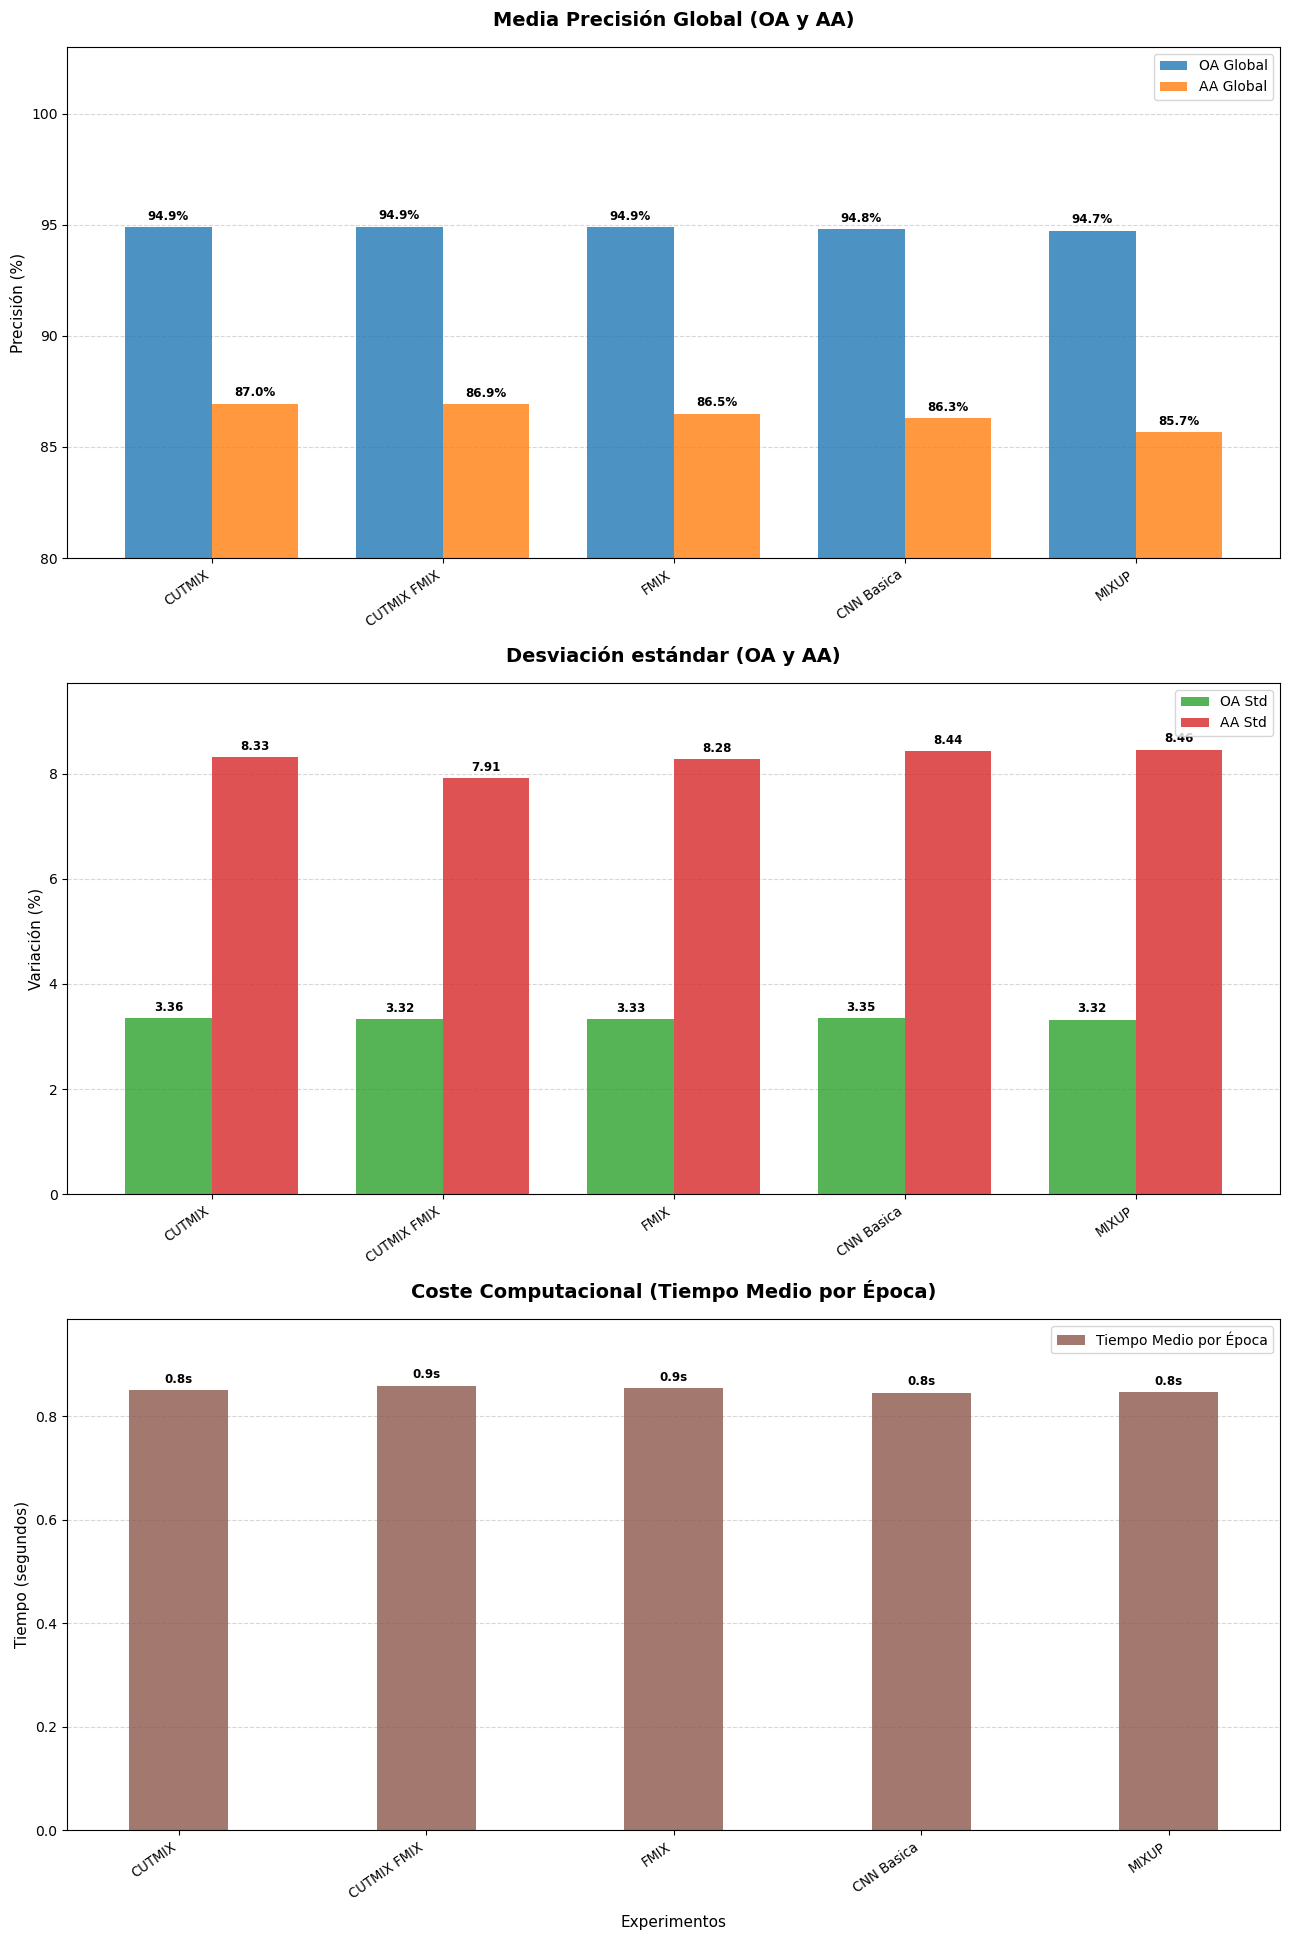

In [8]:
graficaComparacionModelos(datos_orig)

## Resultados usando el aumentado de la clase minoritaria en el dataloader

In [9]:
ruta_carpeta = "Codigos_AumentadoClaseMinoritaria/resultadosPruebasAumentado"

datos_aum=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_FMIX_aumentado.log ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
        oitaven   94.97        0.15   92.55        0.69             52.30                0.5230
     das_mestas   90.83        0.10   89.00        0.26             95.33                0.9533
      eiras_dam   95.30        0.37   89.58        2.03             38.55                0.3855
  ermidas_creek   97.99        0.13   96.26        0.30             58.78                0.5878
ferreiras_river   91.37        0.13   78.29        1.22            131.89                1.3189
     mera_river   90.71        0.09   76.03        4.67            151.90                1.5190
           ulla   98.62        0.48   98.38        0.58              4.59                0.0459
          xesta   98.09        0.09   92.50        1.02            148.27     

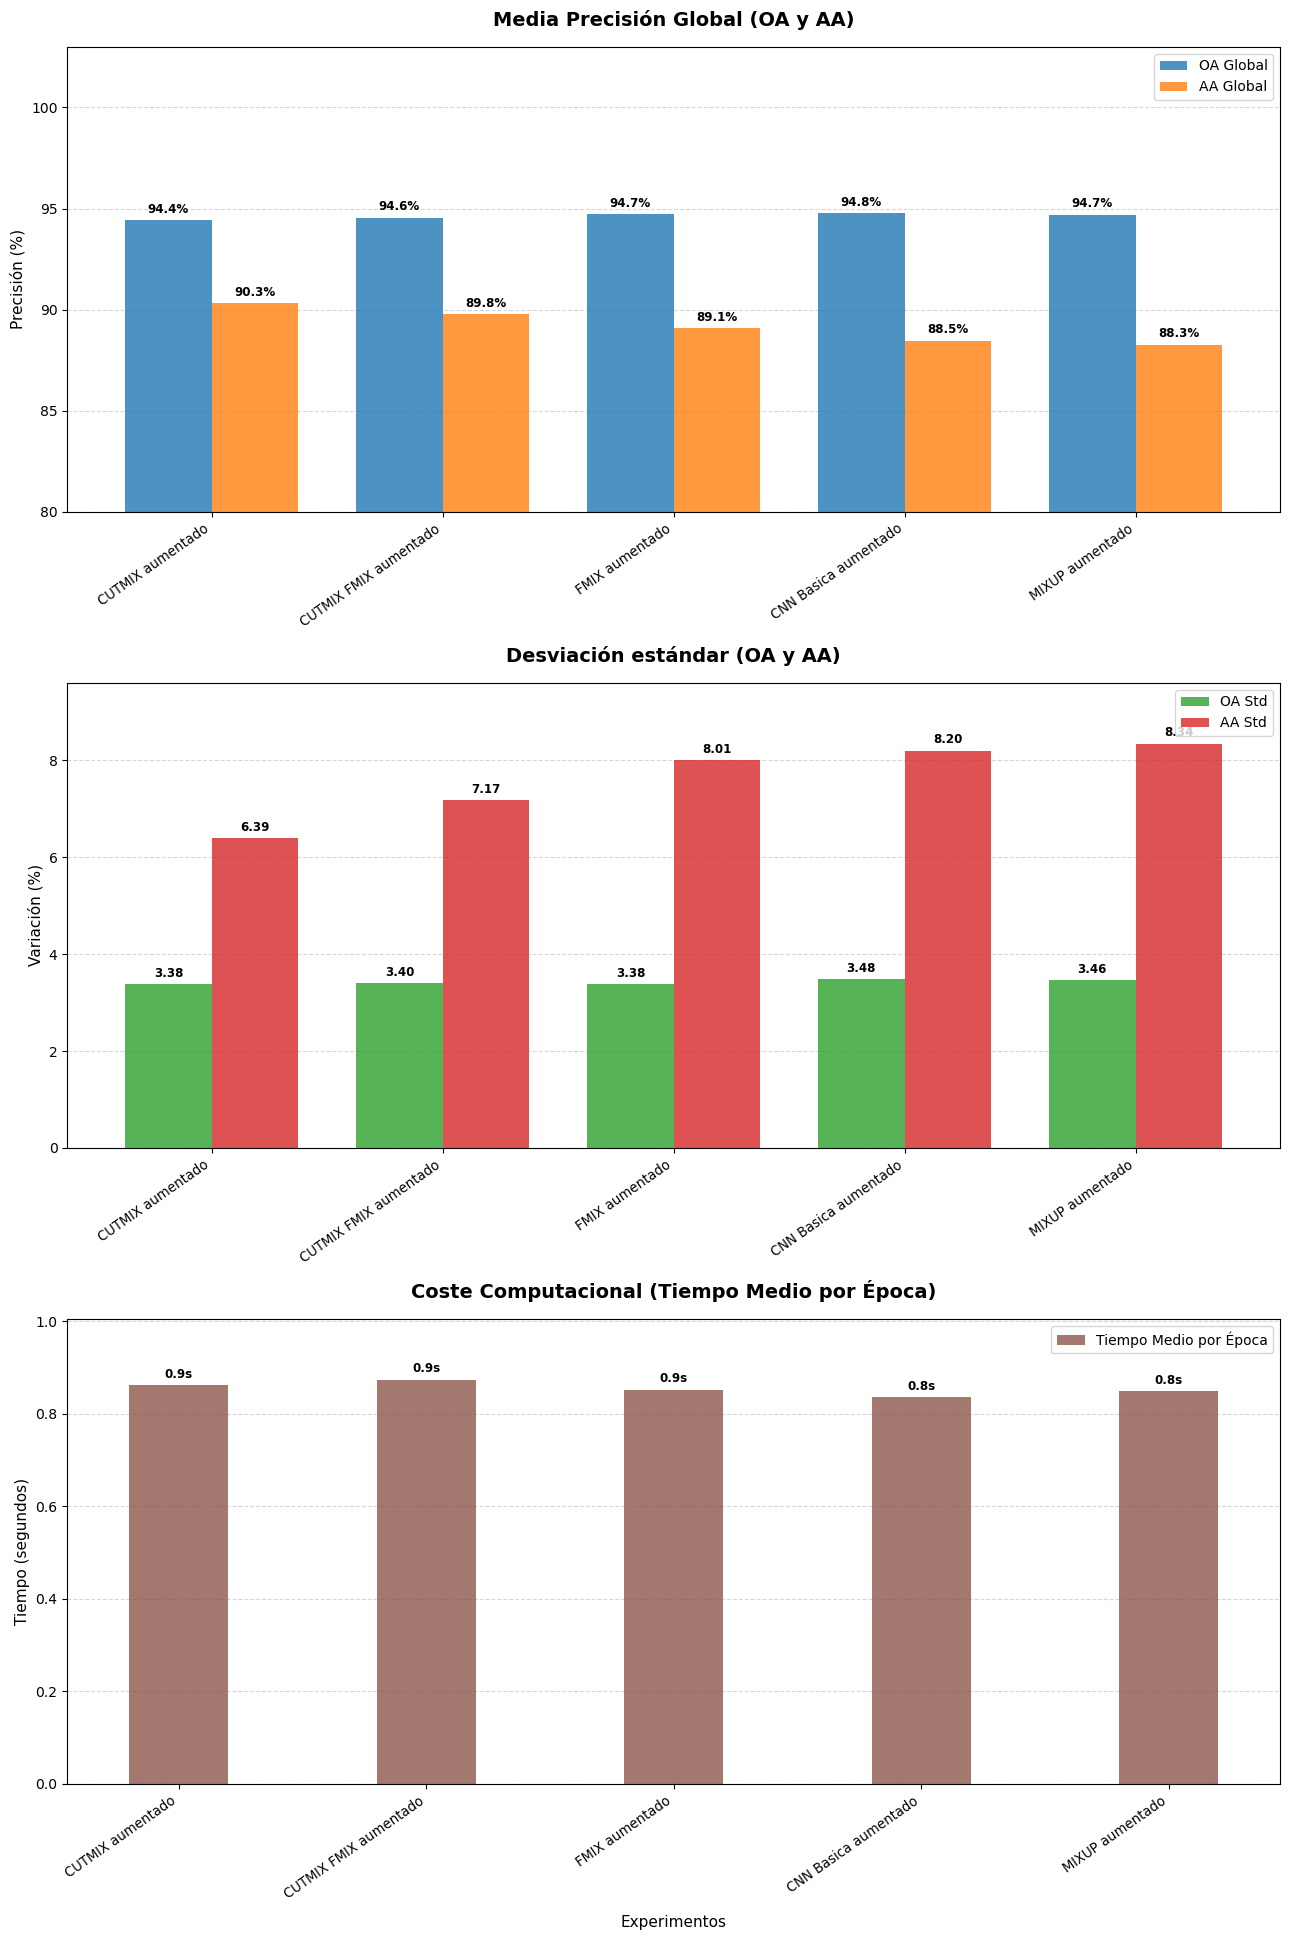

In [10]:
graficaComparacionModelos(datos_aum)

## Comparación de cada versión


=== TABLA RESUMEN GLOBAL COMPARATIVA (Media ± Desviación) ===
     Prueba OA (Original) OA (Aumentado) AA (Original) AA (Aumentado)
     CUTMIX  94.90 ± 3.36   94.41 ± 3.38  86.95 ± 8.33   90.34 ± 6.39
CUTMIX FMIX  94.91 ± 3.32   94.56 ± 3.40  86.92 ± 7.91   89.80 ± 7.17
       FMIX  94.90 ± 3.33   94.73 ± 3.38  86.50 ± 8.28   89.07 ± 8.01
 CNN Basica  94.81 ± 3.35   94.80 ± 3.48  86.28 ± 8.44   88.47 ± 8.20
      MIXUP  94.73 ± 3.32   94.70 ± 3.46  85.66 ± 8.46   88.28 ± 8.34


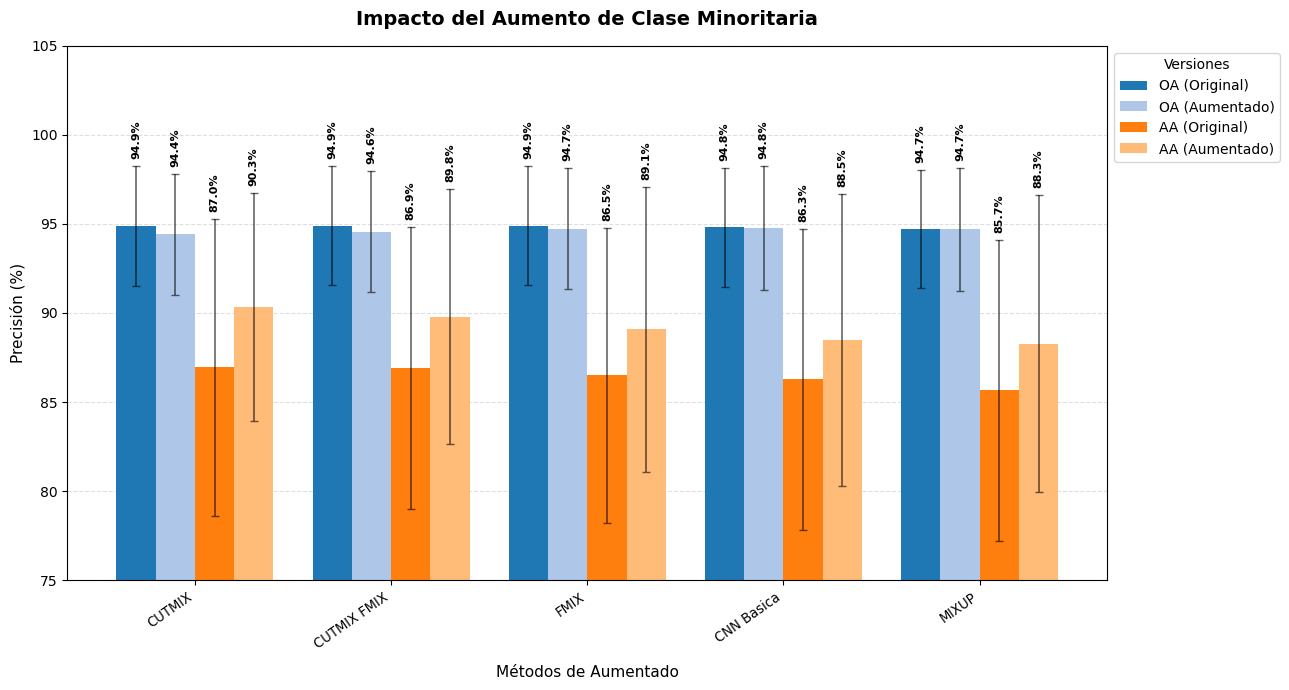

In [11]:
# UNIFICAR LOS DATOS PARA LA COMPARACIÓN ---
datos_comparacion = []

if datos_orig and datos_aum:
    # Convertimos la lista de diccionarios de la carpeta aumentada en un diccionario
    # donde la clave sea el nombre de la prueba (quitando el sufijo "_aumentado") para poder buscar fácilmente su pareja original.
    dict_aum = {d["Prueba"].replace("_aumentado", ""): d for d in datos_aum}

    for d_orig in datos_orig:
        nombre_base = d_orig["Prueba"]
        
        # Si la prueba original tiene su respectiva versión aumentada, las combinamos
        if nombre_base in dict_aum:
            d_aum = dict_aum[nombre_base]
            datos_comparacion.append({
                "Prueba": nombre_base,
                "OA_Orig": d_orig["OA Global (%)"],
                "OA_Aum": d_aum["OA Global (%)"],
                "AA_Orig": d_orig["AA Global (%)"],
                "AA_Aum": d_aum["AA Global (%)"],
                "OA_Std_Orig": d_orig["OA Std (%)"],
                "OA_Std_Aum": d_aum["OA Std (%)"],
                "AA_Std_Orig": d_orig["AA Std (%)"],
                "AA_Std_Aum": d_aum["AA Std (%)"]
            })

# GRÁFICA Y TABLA COMPARATIVA GLOBAL ---
if datos_comparacion:
    df_comp = pd.DataFrame(datos_comparacion)
    # Ordenamos de mayor a menor basándonos en AA_Aum
    df_comp = df_comp.sort_values(by='AA_Aum', ascending=False)
    
    #Reemplazar guiones bajos por espacios en los nombres de las pruebas
    if 'Prueba' in df_comp.columns:
        df_comp['Prueba'] = df_comp['Prueba'].str.replace('_', ' ')
    
    # Definimos las columnas que queremos mostrar y graficar
    cols_medias = ['OA_Orig', 'OA_Aum', 'AA_Orig', 'AA_Aum']
    cols_stds = ['OA_Std_Orig', 'OA_Std_Aum', 'AA_Std_Orig', 'AA_Std_Aum']
    nombres_legibles = ['OA (Original)', 'OA (Aumentado)', 'AA (Original)', 'AA (Aumentado)']

    print("\n" + "="*80)
    print("=== TABLA RESUMEN GLOBAL COMPARATIVA (Media ± Desviación) ===")
    print("="*80)
    
    # Creamos el dataframe resumen con formato Media ± Desviación
    df_resumen = pd.DataFrame()
    df_resumen['Prueba'] = df_comp['Prueba']
    df_resumen['OA (Original)'] = df_comp.apply(lambda x: f"{x['OA_Orig']:.2f} ± {x['OA_Std_Orig']:.2f}", axis=1)
    df_resumen['OA (Aumentado)'] = df_comp.apply(lambda x: f"{x['OA_Aum']:.2f} ± {x['OA_Std_Aum']:.2f}", axis=1)
    df_resumen['AA (Original)'] = df_comp.apply(lambda x: f"{x['AA_Orig']:.2f} ± {x['AA_Std_Orig']:.2f}", axis=1)
    df_resumen['AA (Aumentado)'] = df_comp.apply(lambda x: f"{x['AA_Aum']:.2f} ± {x['AA_Std_Aum']:.2f}", axis=1)
    
    print(df_resumen.to_string(index=False))
    
    # Preparación para la gráfica
    df_plot_medias = df_comp[['Prueba'] + cols_medias].set_index('Prueba')
    df_plot_stds = df_comp[['Prueba'] + cols_stds].set_index('Prueba')
    
    # Renombrar columnas para la leyenda de la gráfica
    df_plot_medias.columns = nombres_legibles
    df_plot_stds.columns = nombres_legibles
    
    colores = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']
    
    # Generamos la gráfica
    ax = df_plot_medias.plot(
        kind='bar', 
        yerr=df_plot_stds.values.T, 
        capsize=3,
        figsize=(13, 7), 
        color=colores,
        width=0.8,
        error_kw={'alpha': 0.6, 'lw': 1.2}
    )
    
    plt.title('Impacto del Aumento de Clase Minoritaria', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Precisión (%)', fontsize=11)
    plt.xlabel('Métodos de Aumentado', fontsize=11, labelpad=10)
    
    plt.xticks(rotation=35, ha='right', fontsize=9.5)
    
    # Ajuste dinámico del eje Y
    lim_inferior = min(df_comp[cols_medias].min().min() - 5, 75)
    plt.ylim(lim_inferior, 105) 
    
    # Rejilla enviada al fondo
    ax.set_axisbelow(True)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Filtramos para aplicar 'bar_label' solo a contenedores de tipo barra
    for container in ax.containers:
        if type(container).__name__ == 'BarContainer':
            ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=8, fontweight='semibold', rotation=90)
    
    # Mover la leyenda arriba a la derecha por fuera
    plt.legend(title='Versiones', loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo se pudieron generar los datos de comparación. Verifica que los archivos base y los '_aumentado' existan.")

CutMix y CutMix + FMIX son los que mejores resultados dan en ambos casos.

MixUp obtiene peores resultados en ambos casos, siendo incluso peor que la CNN básica.

 

Existen casos donde hay clases muy poco representadas, como la clase 9 en ferreiras_river, donde representa el 0.02% del dataset, en este caso la red no logra sacar patrones para reconocer esta clase debido a que existen muy pocos píxeles de la misma, haciendo que el rendimiento apenas aumente.



# Comportamiento de las distintas versiones por cada dataset

In [12]:
# DICCIONARIO GLOBAL DE COLORES
PALETA_COLORES = {
    # FASE 1:
    # CNN Básica
    "CNN_Basica": "#6baed6",                 
    "CNN_Basica_PyTorch": "#6baed6",
    "CNN_Basica_Aum": "#1f77b4",             
    "CNN_Basica_Aumento": "#1f77b4",
    
    #CutMix
    "CUTMIX": "#a1d99b",                     
    "CUTMIX_PyTorch": "#a1d99b",
    "CUTMIX_Aum": "#2ca02c",                 
    "CUTMIX_Aumento": "#2ca02c",
    
    #FMix
    "FMIX": "#c49c94",                       
    "FMIX_PyTorch": "#c49c94",
    "FMIX_Aum": "#8c564b",                   
    "FMIX_Aumento": "#8c564b",
    
    #MixUp
    "MIXUP": "#c7c7c7",                      
    "MIXUP_PyTorch": "#c7c7c7",
    "MIXUP_Aum": "#7f7f7f",                  
    "MIXUP_Aumento": "#7f7f7f",
    
    #CutMix + FMix
    "CUTMIX_FMIX": "#9edae5",                
    "CUTMIX_FMIX_PyTorch": "#9edae5",
    "CUTMIX_FMIX_Aum": "#17becf",            
    "CUTMIX_FMIX_Aumento": "#17becf",


    # FASES 3 y 4
    "VIT_Basica": "#e377c2",                
    "VIT_Basica_Aumentado": "#9467bd",       
    "VIT+CUTMIX": "#ff7f0e",                 
    "VIT+CUTMIX+FMIX": "#d62728",            

    # FASE 2
    "0, Flips": "#bcbd22",                   
    "1, Rotación": "#aec7e8",
    "3, Rotación_Zoom": "#ffbb78",
    "11, Rotación_Borrado Aleatorio": "#f7b6d2",
    "12, Rotación_Zoom_Borrado Aleatorio": "#dbdb8d"
}

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

Generando gráficas para: das_mestas...


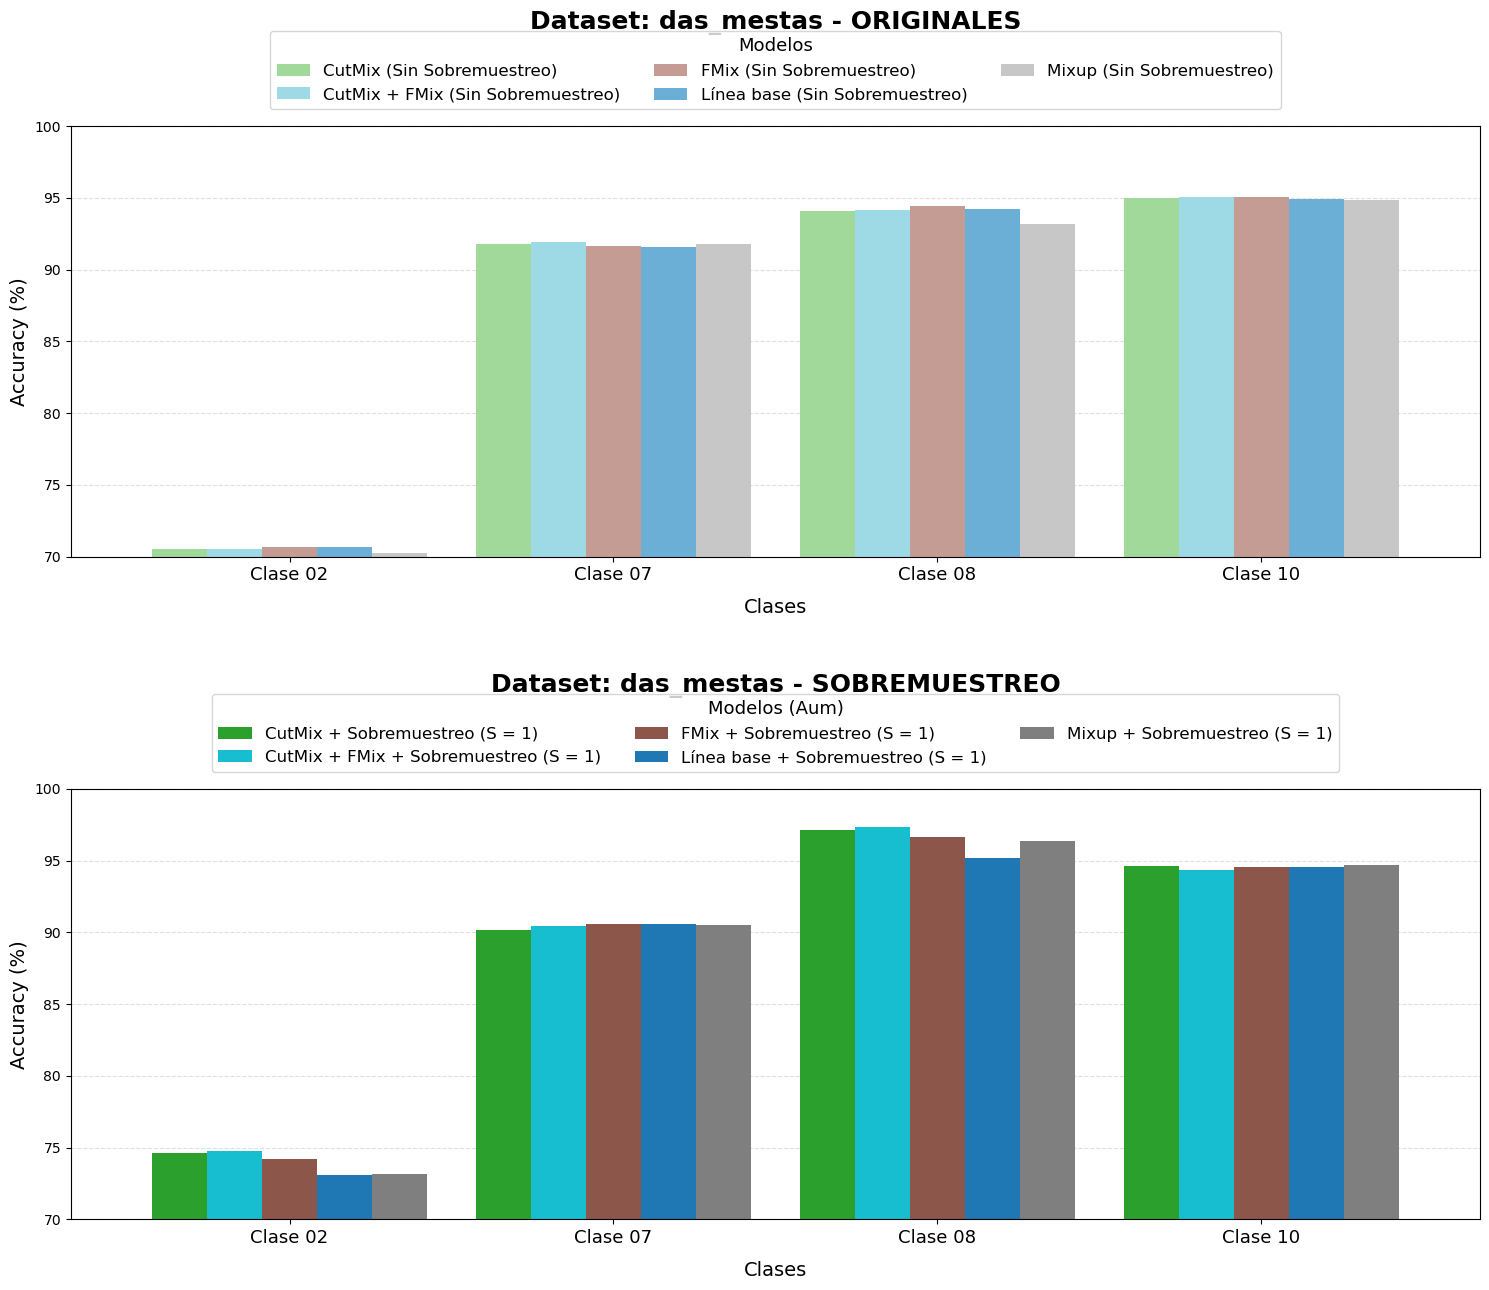


Generando gráficas para: eiras_dam...


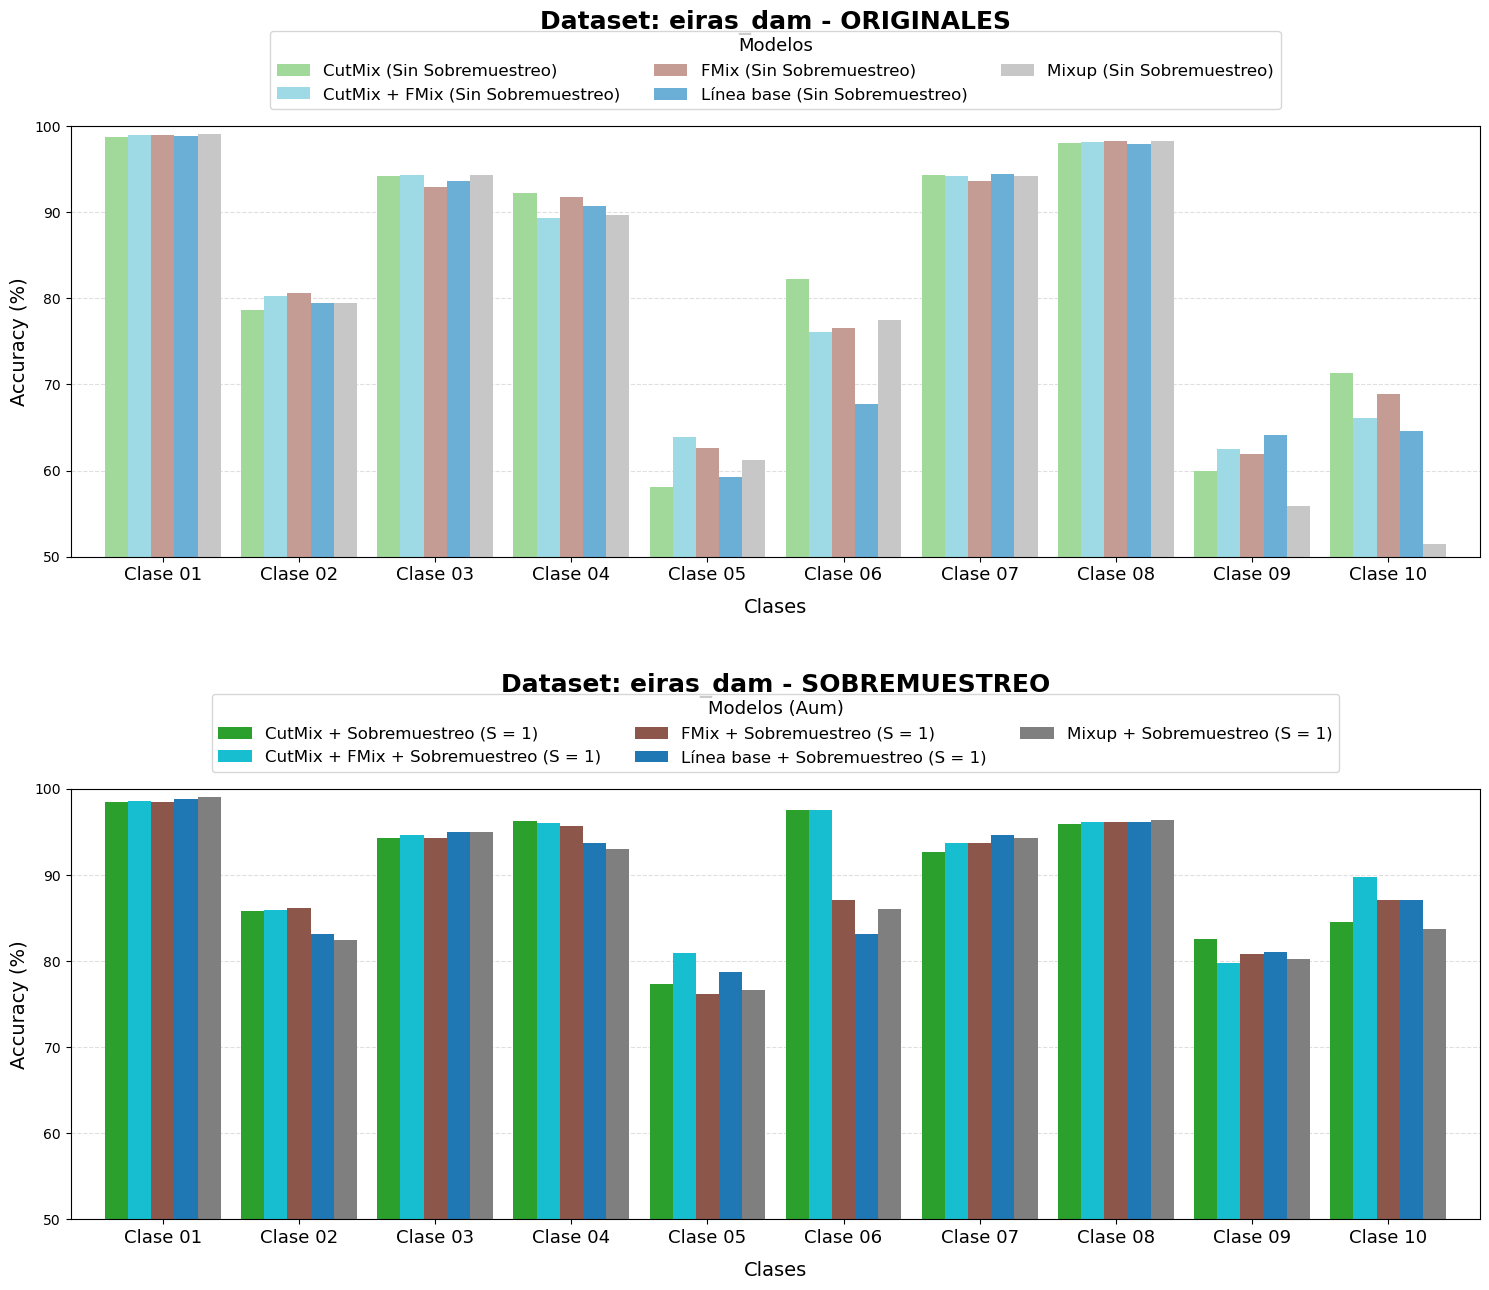


Generando gráficas para: ermidas_creek...


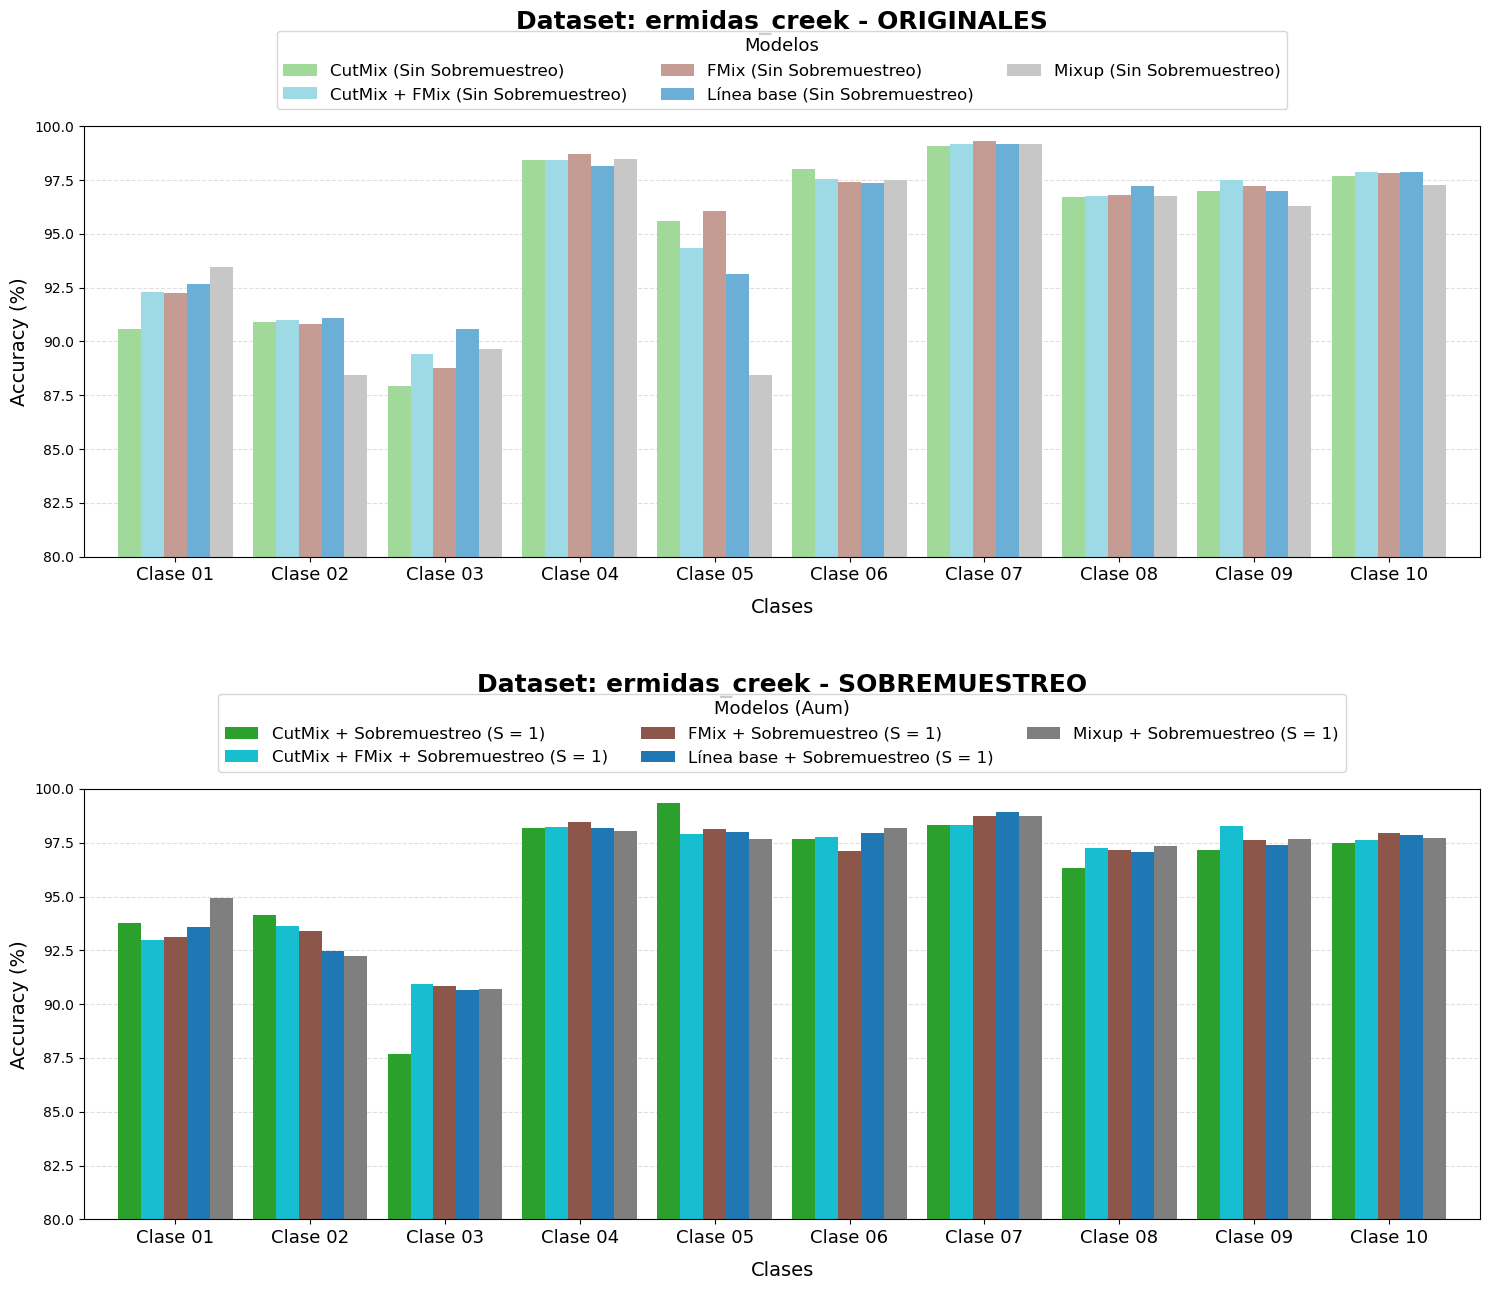


Generando gráficas para: ferreiras_river...


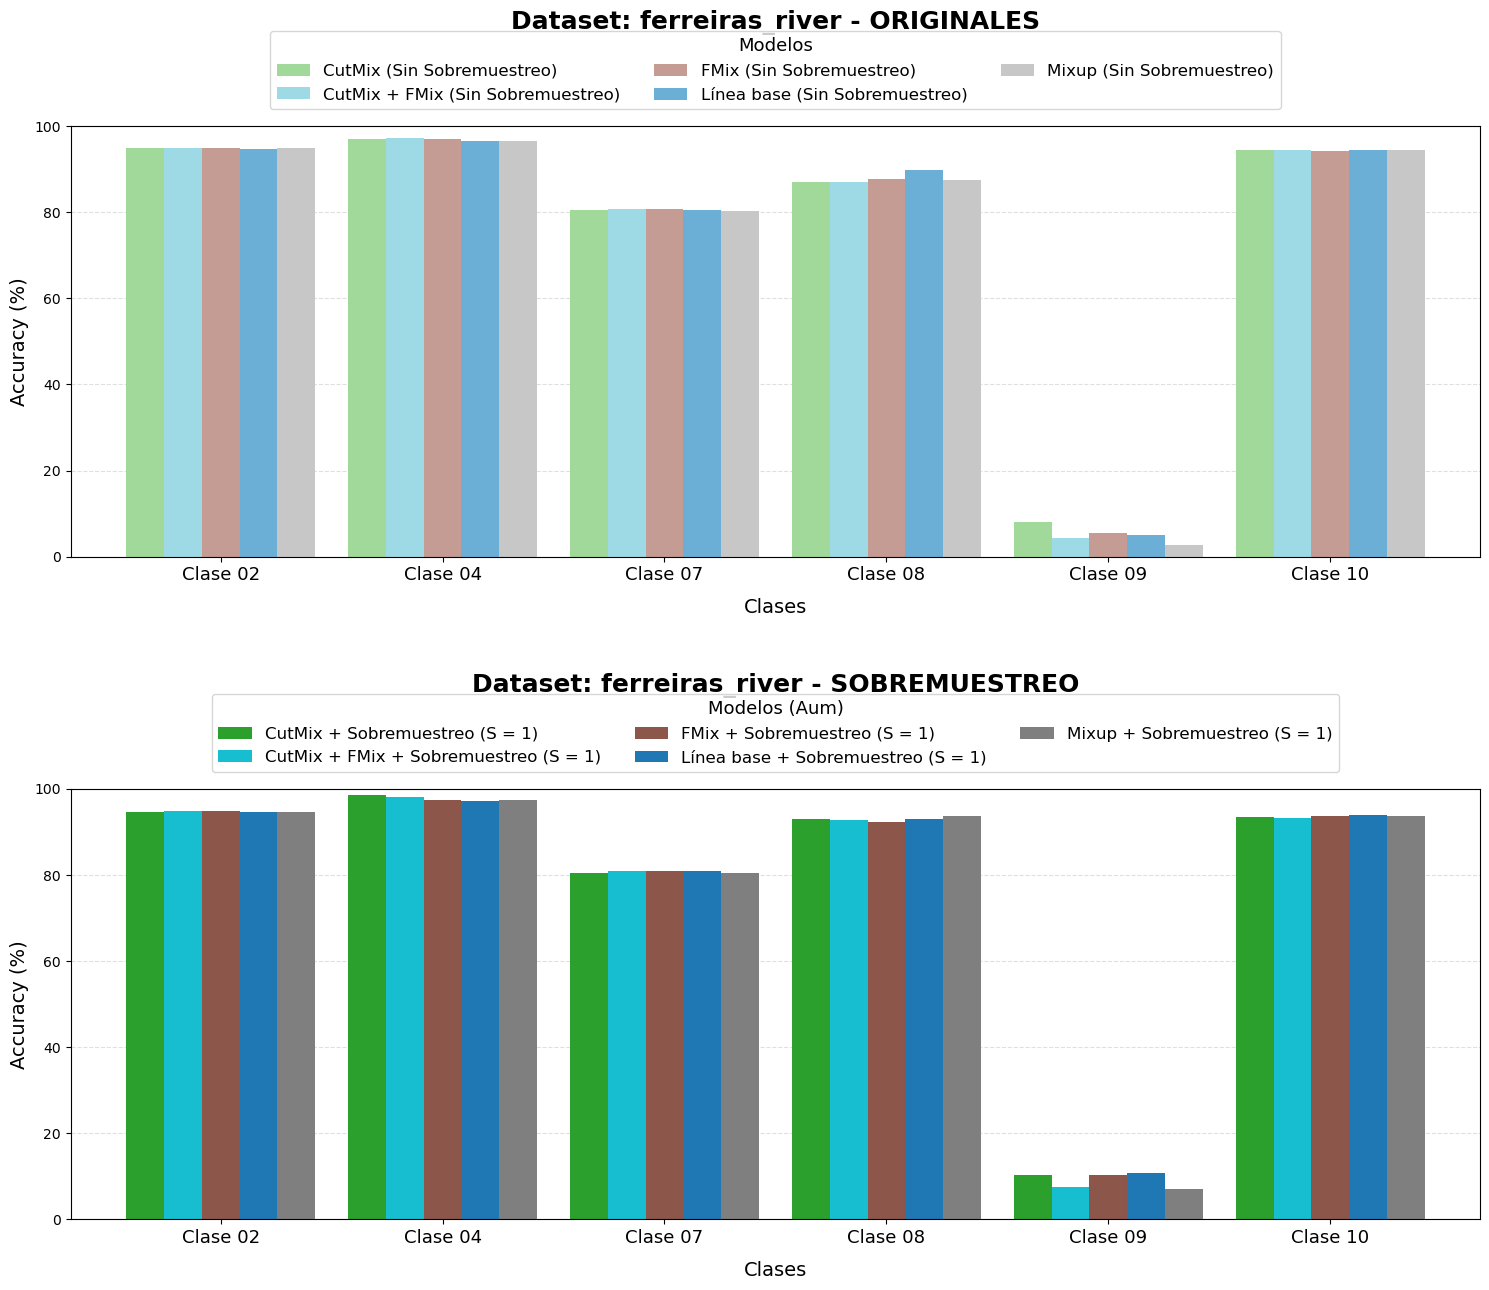


Generando gráficas para: mera_river...


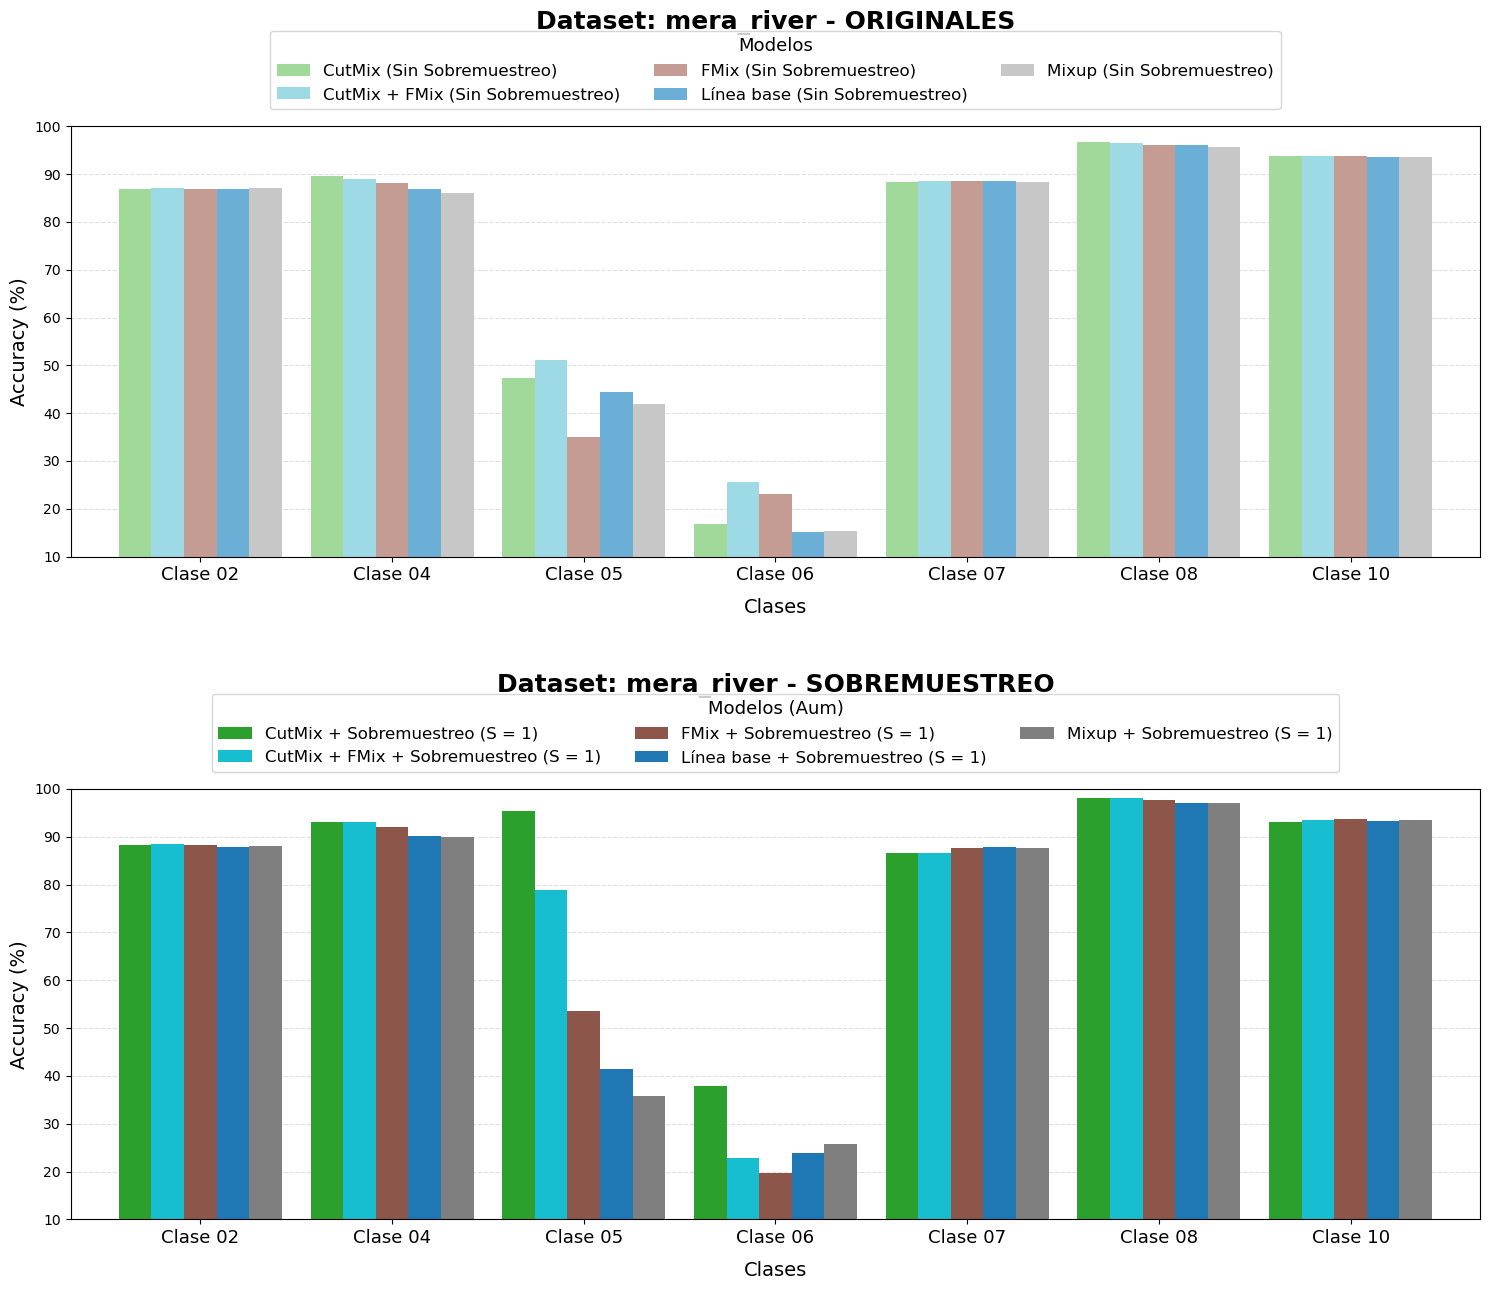


Generando gráficas para: oitaven...


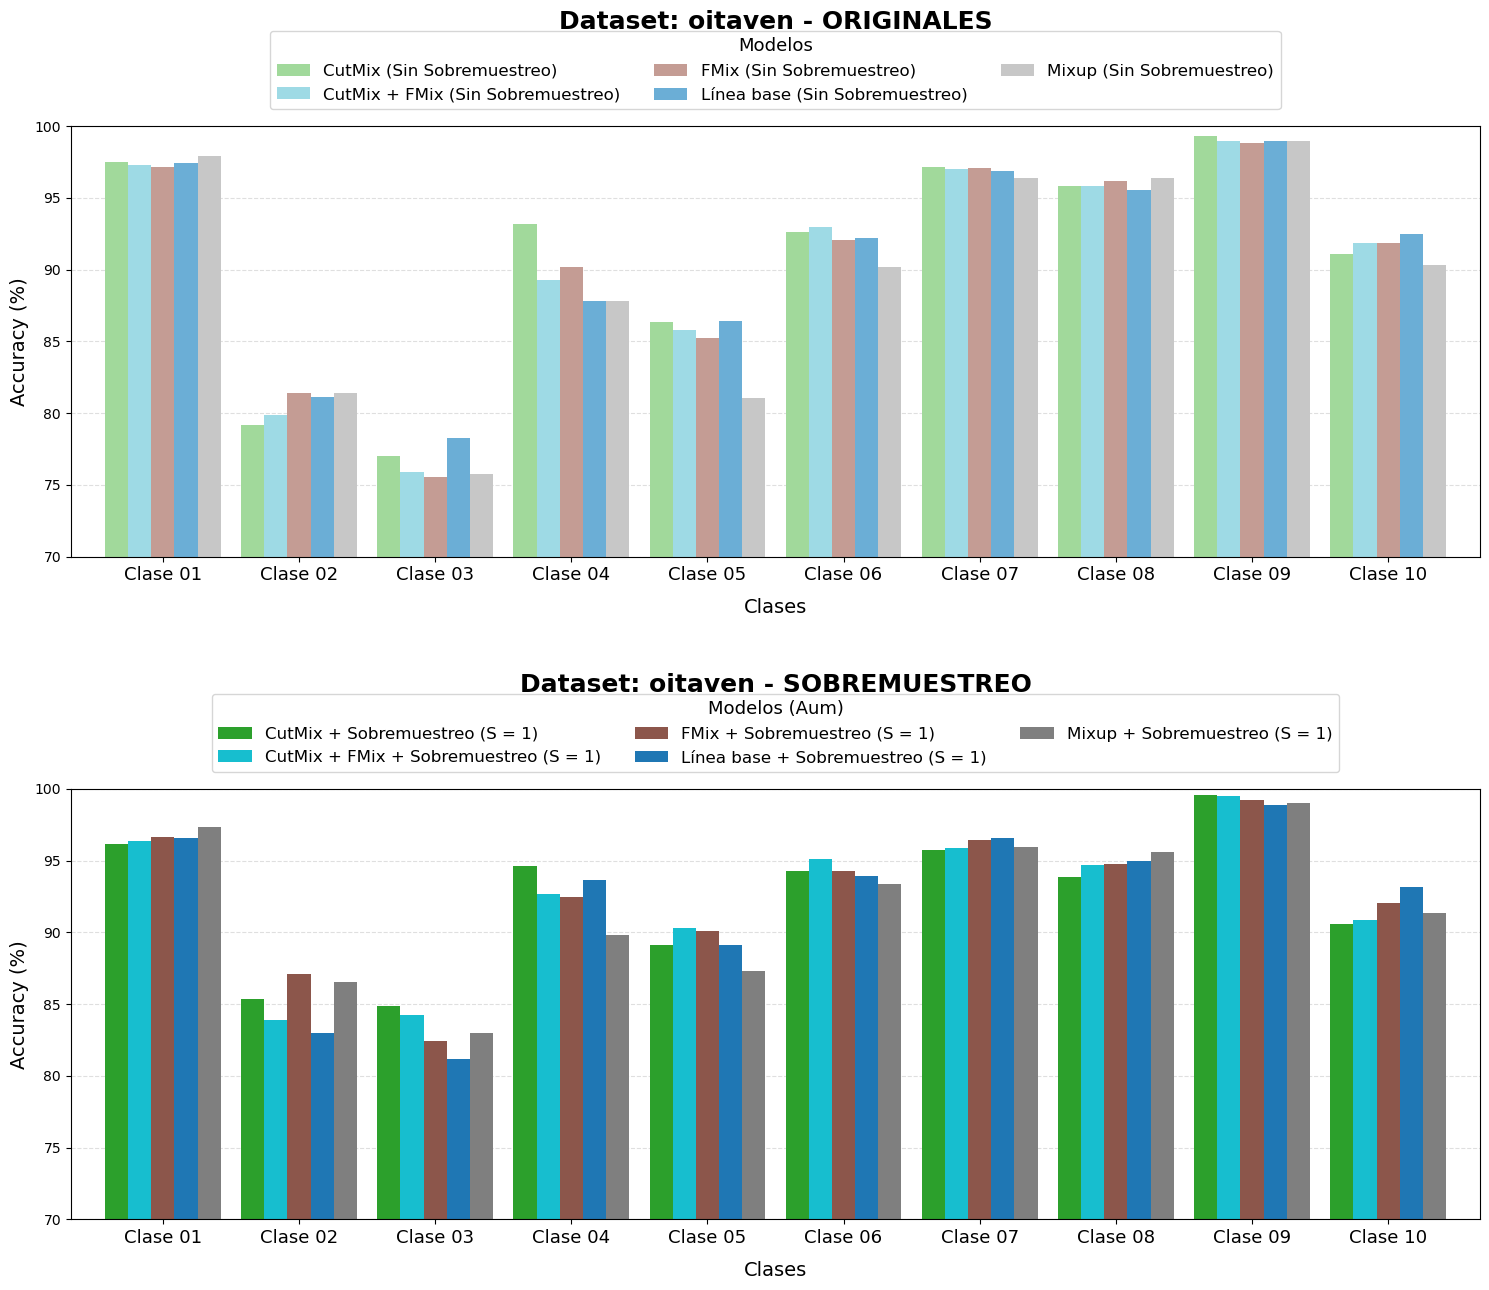


Generando gráficas para: ulla...


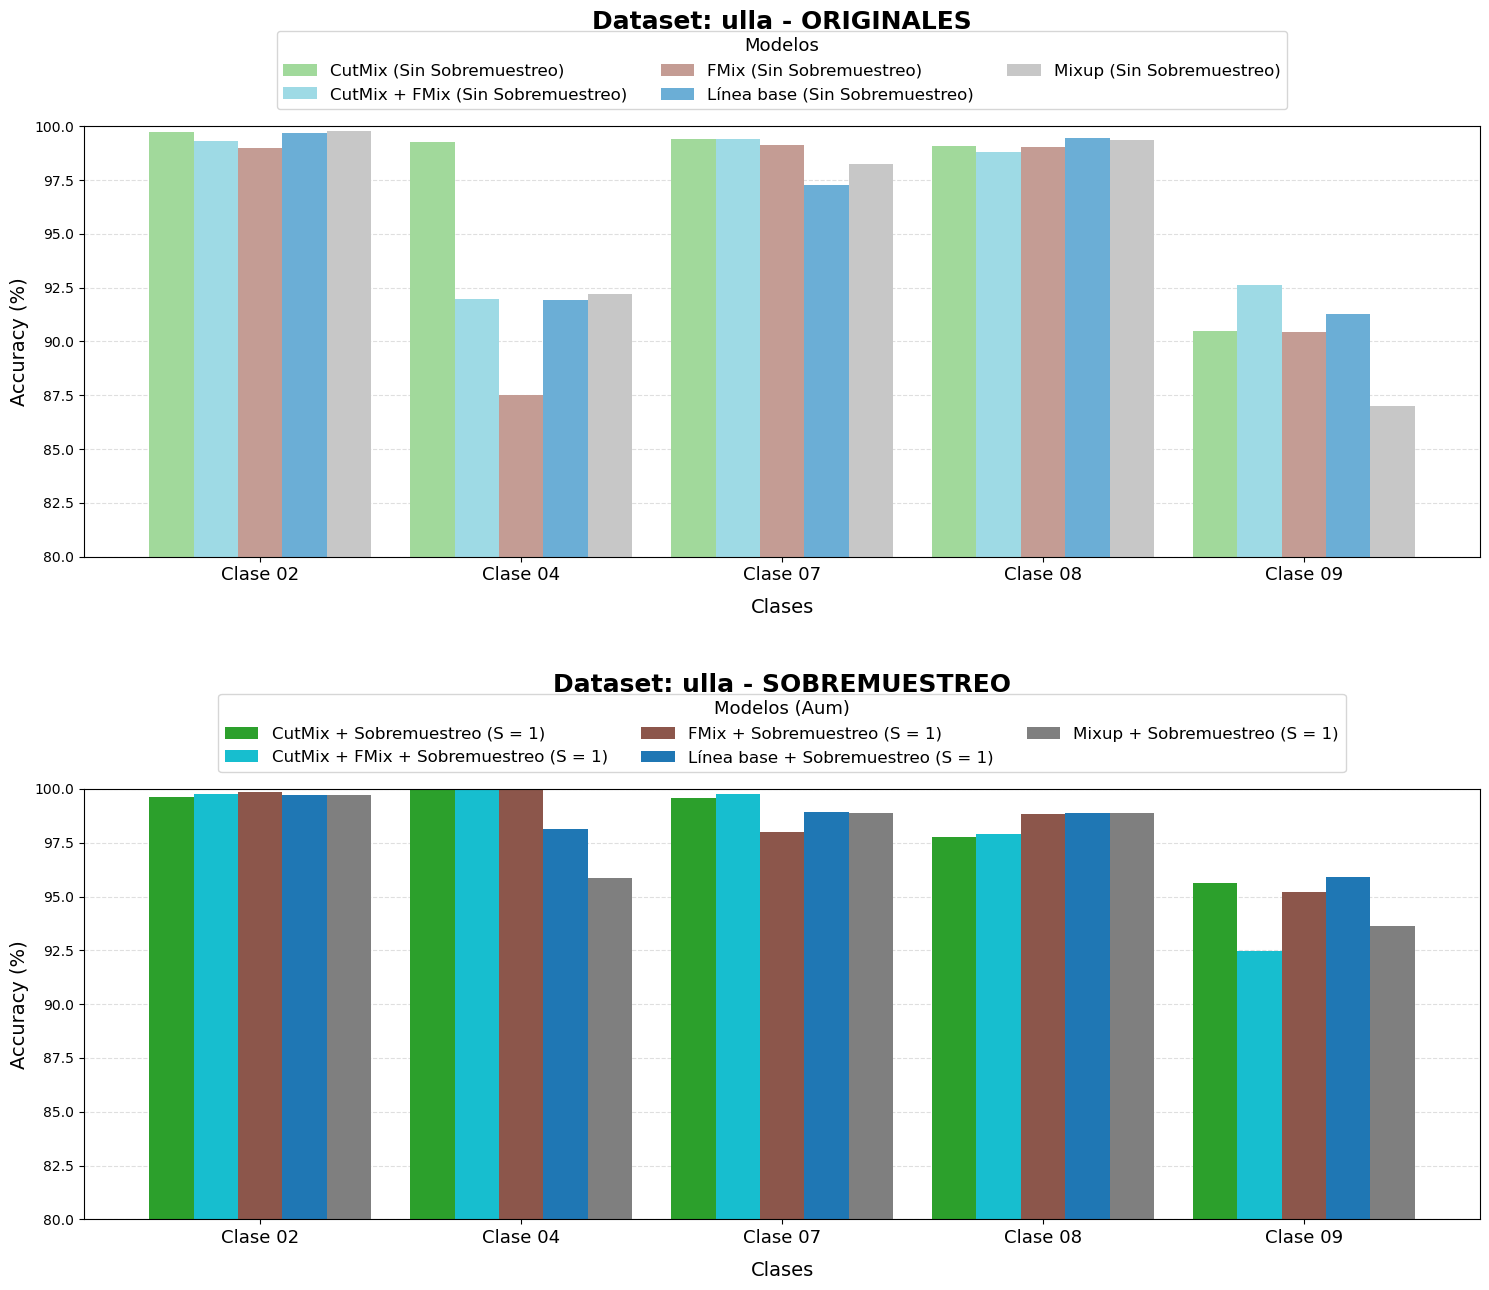


Generando gráficas para: xesta...


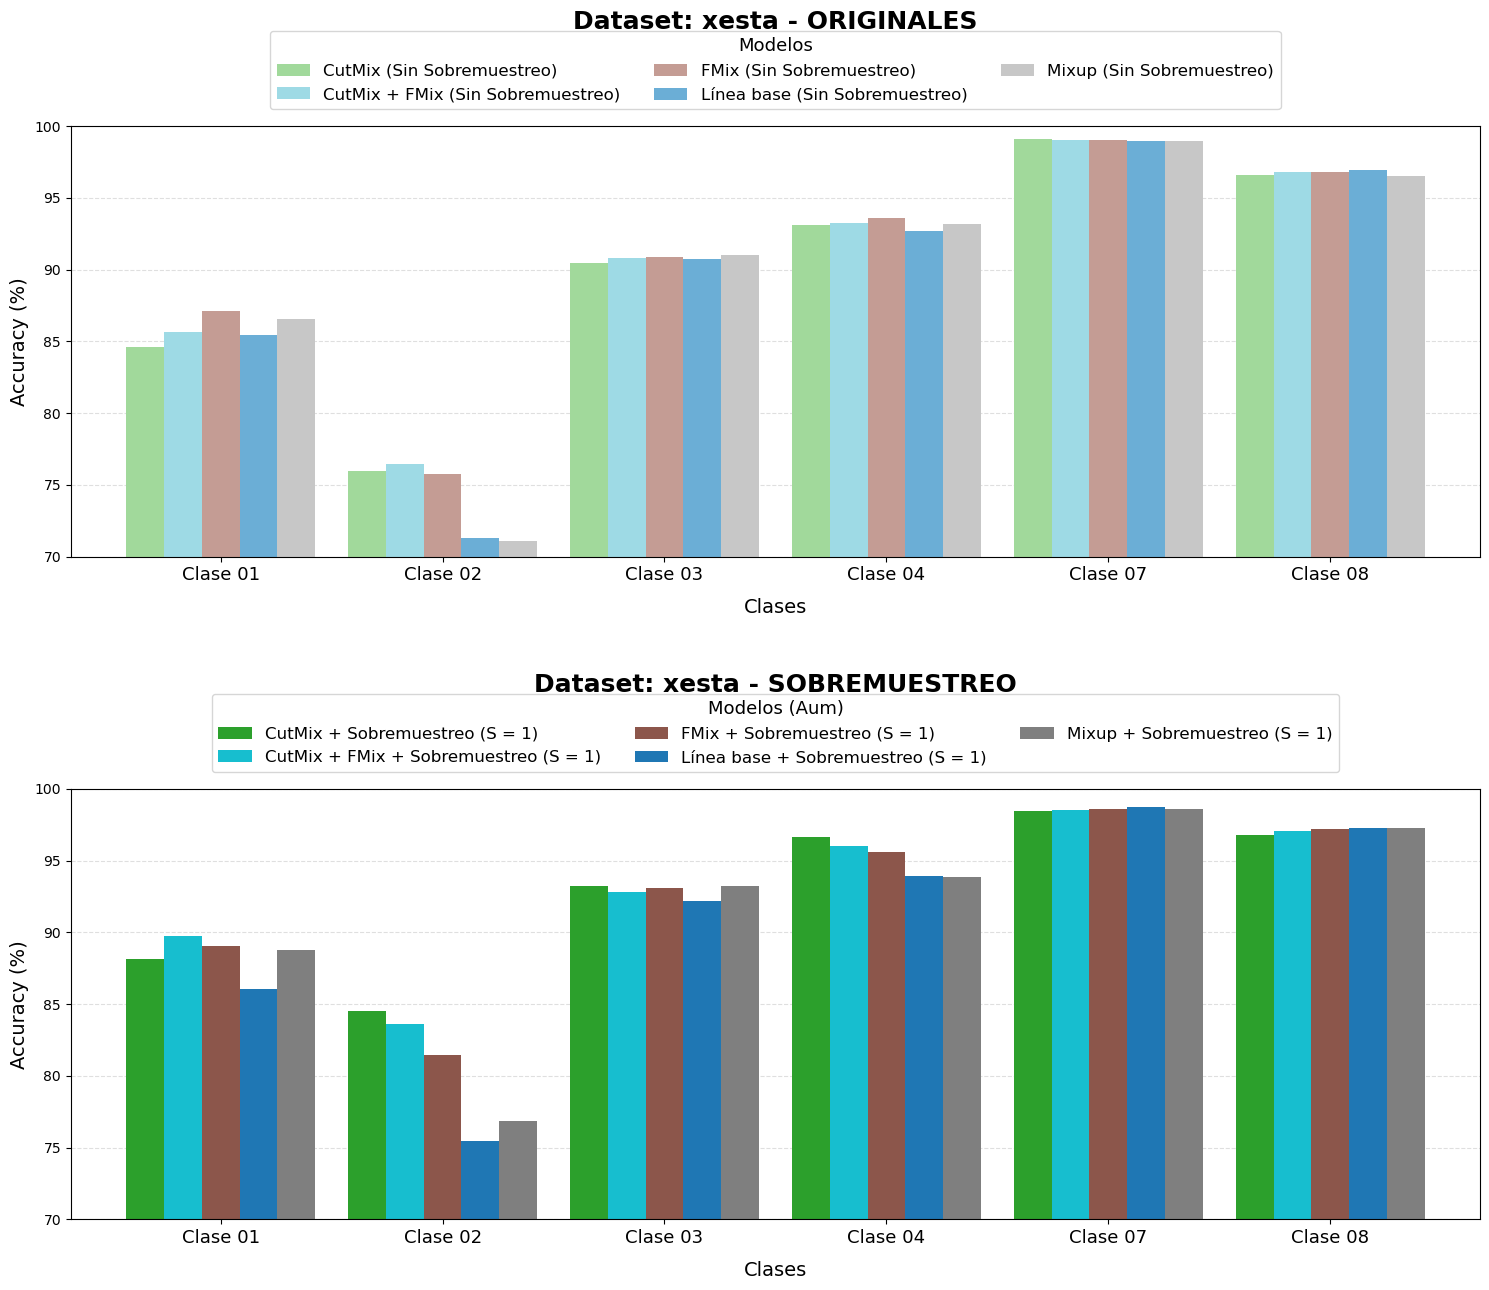

In [13]:
import glob
import math
import os
import matplotlib.pyplot as plt
import pandas as pd

def graficar_clases_separado_limpio(dataset_objetivo):
    modelos_base = ["CNN_Basica", "CUTMIX", "FMIX", "MIXUP", "CUTMIX_FMIX"]
    df_original = pd.DataFrame()
    df_aumentado = pd.DataFrame()

    # 1. Recolección de datos
    for modelo in modelos_base:
        ruta_orig = os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebas", f"resultados_{modelo}.log")
        ruta_aum = os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebasAumentado", f"resultados_{modelo}_aumentado.log")
        
        # Procesar originales
        if os.path.exists(ruta_orig):
            _, _, df_clases_orig = procesar_log_detallado(ruta_orig)
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                df_original[modelo] = df_clases_orig.loc[dataset_objetivo]
        
        # Procesar aumentados
        if os.path.exists(ruta_aum):
            _, _, df_clases_aum = procesar_log_detallado(ruta_aum)
            if df_clases_aum is not None and dataset_objetivo in df_clases_aum.index:
                df_aumentado[modelo] = df_clases_aum.loc[dataset_objetivo]

    # 2. Filtrado: Eliminar clases vacías o con valores cero
    if not df_original.empty:
        df_original = df_original.dropna(how='all') 
        df_original = df_original[(df_original > 0).any(axis=1)] 
    
    if not df_aumentado.empty:
        df_aumentado = df_aumentado.dropna(how='all')
        df_aumentado = df_aumentado[(df_aumentado > 0).any(axis=1)]

    if df_original.empty and df_aumentado.empty:
        print(f"No hay datos para {dataset_objetivo}")
        return

    # Definir orden de visualización y mapeo de nombres
    orden_ranking = ["CUTMIX", "CUTMIX_FMIX", "FMIX", "CNN_Basica", "MIXUP"]
    
    nombres_originales = {
        "CUTMIX": "CutMix (Sin Sobremuestreo)",
        "CUTMIX_FMIX": "CutMix + FMix (Sin Sobremuestreo)",
        "FMIX": "FMix (Sin Sobremuestreo)",
        "CNN_Basica": "Línea base (Sin Sobremuestreo)",
        "MIXUP": "Mixup (Sin Sobremuestreo)"
    }
    
    nombres_aumentados = {
        "CUTMIX": "CutMix + Sobremuestreo (S = 1)",
        "CUTMIX_FMIX": "CutMix + FMix + Sobremuestreo (S = 1)",
        "FMIX": "FMix + Sobremuestreo (S = 1)",
        "CNN_Basica": "Línea base + Sobremuestreo (S = 1)",
        "MIXUP": "Mixup + Sobremuestreo (S = 1)"
    }

    if not df_original.empty:
        cols_orig_validas = [c for c in orden_ranking if c in df_original.columns]
        df_original = df_original[cols_orig_validas]
        labels_orig_limpios = [nombres_originales[c] for c in df_original.columns]

    if not df_aumentado.empty:
        cols_aum_validas = [c for c in orden_ranking if c in df_aumentado.columns]
        df_aumentado = df_aumentado[cols_aum_validas]
        labels_aum_limpios = [nombres_aumentados[c] for c in df_aumentado.columns]

    # 3. Cálculo del ymin dinámico
    todos_valores = pd.concat([df_original, df_aumentado]).values.flatten()
    valores_validos = [v for v in todos_valores if v > 0 and not pd.isna(v)]
    ymin = (min(valores_validos) // 10) * 10 if valores_validos else 0

    # 4. Generación de gráficas
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 13))

    # --- Gráfica 1: Originales ---
    if not df_original.empty:
        colores_orig = [PALETA_COLORES.get(col, "#d3d3d3") for col in df_original.columns]
        
        df_original.plot(kind='bar', ax=ax1, width=0.85, color=colores_orig)
        
        ax1.set_title(f'Dataset: {dataset_objetivo} - ORIGINALES', fontsize=18, fontweight='bold', pad=70)
        ax1.set_ylabel('Accuracy (%)', fontsize=14)
        ax1.set_ylim(ymin, 100) 
        
        ax1.set_axisbelow(True)
        ax1.grid(axis='y', linestyle='--', alpha=0.4)
            
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=13)
        ax1.set_xlabel('Clases', fontsize=14, labelpad=10) 
        
        ax1.legend(
            labels=labels_orig_limpios,
            title="Modelos", 
            loc='lower center', 
            bbox_to_anchor=(0.5, 1.02), 
            ncol=3, 
            fontsize=12,
            title_fontsize=13
        )

    # --- Gráfica 2: Aumentados ---
    if not df_aumentado.empty:
        colores_aum = [PALETA_COLORES.get(f"{col}_Aumento", "#d3d3d3") for col in df_aumentado.columns]
        
        df_aumentado.plot(kind='bar', ax=ax2, width=0.85, color=colores_aum)
        
        ax2.set_title(f'Dataset: {dataset_objetivo} - SOBREMUESTREO', fontsize=18, fontweight='bold', pad=70)
        ax2.set_ylabel('Accuracy (%)', fontsize=14)
        ax2.set_xlabel('Clases', fontsize=14, labelpad=10)
        ax2.set_ylim(ymin, 100) 
        
        ax2.set_axisbelow(True)
        ax2.grid(axis='y', linestyle='--', alpha=0.4)
            
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, ha='center', fontsize=13)
        
        ax2.legend(
            labels=labels_aum_limpios,
            title="Modelos (Aum)", 
            loc='lower center', 
            bbox_to_anchor=(0.5, 1.02), 
            ncol=3,
            fontsize=12,
            title_fontsize=13
        )

    # Ajustar espaciado vertical entre gráficas
    plt.tight_layout(h_pad=4.0)
    plt.show()

# Obtener lista de datasets desde los logs
def obtener_lista_datasets():
    archivos = glob.glob(os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebas", "*.log"))
    if not archivos:
        return []
    
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# Ejecución del script
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        print(f"\nGenerando gráficas para: {ds}...")
        graficar_clases_separado_limpio(ds)

In [14]:
import glob
import os
import pandas as pd

def imprimir_tabla_clases_dataset(dataset_objetivo):
    modelos_base = ["CNN_Basica", "CUTMIX", "FMIX", "MIXUP", "CUTMIX_FMIX"]
    filas_datos = {}

    # 1. Recolección de datos
    for modelo in modelos_base:
        ruta_orig = os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebas", f"resultados_{modelo}.log")
        ruta_aum = os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebasAumentado", f"resultados_{modelo}_aumentado.log")
        
        # Procesar logs originales
        if os.path.exists(ruta_orig):
            _, _, df_clases_orig = procesar_log_detallado(ruta_orig)
            if df_clases_orig is not None and dataset_objetivo in df_clases_orig.index:
                filas_datos[modelo] = df_clases_orig.loc[dataset_objetivo]
        
        # Procesar logs aumentados
        if os.path.exists(ruta_aum):
            _, _, df_clases_aum = procesar_log_detallado(ruta_aum)
            if df_clases_aum is not None and dataset_objetivo in df_clases_aum.index:
                filas_datos[f"{modelo}_Aum"] = df_clases_aum.loc[dataset_objetivo]

    if not filas_datos:
        print(f"No hay datos para {dataset_objetivo}\n")
        return

    # 2. Creación del DataFrame
    df_tabla = pd.DataFrame.from_dict(filas_datos, orient='index')

    # Establecer orden establecido para las configuraciones
    orden_ranking_aa = [
        "CUTMIX_Aum",       
        "CUTMIX_FMIX_Aum",  
        "FMIX_Aum",         
        "CNN_Basica_Aum",   
        "MIXUP_Aum",        
        "CUTMIX",           
        "CUTMIX_FMIX",      
        "FMIX",             
        "CNN_Basica",       
        "MIXUP"             
    ]

    # Diccionario de mapeo de etiquetas
    nombres_legibles = {
        "CUTMIX_Aum": "CutMix + Sobremuestreo (S = 1)",
        "CUTMIX_FMIX_Aum": "CutMix + FMix + Sobremuestreo (S = 1)",
        "FMIX_Aum": "FMix + Sobremuestreo (S = 1)",
        "CNN_Basica_Aum": "Línea base (CNN Básica) + Sobremuestreo (S = 1)",
        "MIXUP_Aum": "Mixup + Sobremuestreo (S = 1)",
        "CUTMIX": "CutMix (Sin Sobremuestreo)",
        "CUTMIX_FMIX": "CutMix + FMix (Sin Sobremuestreo)",
        "FMIX": "FMix (Sin Sobremuestreo)",
        "CNN_Basica": "Línea base (Sin Sobremuestreo)",
        "MIXUP": "Mixup (Sin Sobremuestreo)"
    }

    # Filtrar claves no cargadas en el DataFrame actual
    orden_existente = [config for config in orden_ranking_aa if config in df_tabla.index]
    
    # Aplicar ordenación y renombrar índices
    df_tabla = df_tabla.reindex(orden_existente)
    df_tabla = df_tabla.rename(index=nombres_legibles)

    # 3. Filtrado
    df_tabla = df_tabla.dropna(axis=1, how='all')
    df_tabla = df_tabla.loc[:, (df_tabla > 0).any(axis=0)]

    if df_tabla.empty:
        print(f"No hay clases válidas con accuracy > 0 para {dataset_objetivo}\n")
        return

    # 4. Formato de visualización
    df_formateado = df_tabla.apply(
        lambda col: col.map(lambda x: f"{x:.2f}" if pd.notna(x) and x > 0 else "   -   ")
    )
    
    df_formateado.index.name = "Configuración"

    print(f"\n************* ACCURACY POR CLASE PARA DATASET: {dataset_objetivo.upper()} *************")
    print(df_formateado.to_string(justify='center'))
    print("="*90)

# Obtener lista de datasets desde los logs
def obtener_lista_datasets():
    archivos = glob.glob(os.path.join("Codigos_AumentadoClaseMinoritaria/resultadosPruebas", "*.log"))
    if not archivos:
        return []
    
    _, _, df_clases = procesar_log_detallado(archivos[0])
    if df_clases is not None:
        return df_clases.index.tolist()
    return []

# Ejecución del script
datasets_disponibles = obtener_lista_datasets()

if not datasets_disponibles:
    print("No se detectaron datasets en los archivos de log.")
else:
    print(f"Datasets detectados: {datasets_disponibles}")
    for ds in datasets_disponibles:
        imprimir_tabla_clases_dataset(ds)

Datasets detectados: ['das_mestas', 'eiras_dam', 'ermidas_creek', 'ferreiras_river', 'mera_river', 'oitaven', 'ulla', 'xesta']

************* ACCURACY POR CLASE PARA DATASET: DAS_MESTAS *************
                                                Clase 02 Clase 07 Clase 08 Clase 10
Configuración                                                                      
CutMix + Sobremuestreo (S = 1)                    74.60    90.17    97.16    94.63 
CutMix + FMix + Sobremuestreo (S = 1)             74.77    90.42    97.37    94.33 
FMix + Sobremuestreo (S = 1)                      74.22    90.60    96.63    94.53 
Línea base (CNN Básica) + Sobremuestreo (S = 1)   73.10    90.61    95.19    94.58 
Mixup + Sobremuestreo (S = 1)                     73.17    90.52    96.37    94.71 
CutMix (Sin Sobremuestreo)                        70.51    91.80    94.09    95.03 
CutMix + FMix (Sin Sobremuestreo)                 70.53    91.92    94.18    95.05 
FMix (Sin Sobremuestreo)                    